# GrIS melt causality

Author: Ziqi Yin

Last modified: 2026 Jun 2

Description: Causal inference of Greenland Ice Sheet summer surface melt
- Method: PCMCI+
- Period: 1975-2014
- Frequency: monthly
- Region: ablation zone
- Variables: SWn, LWn, SH, LH
- Source: RACMO2.3p2

In [1]:
import numpy as np
import xarray as xr
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms
from matplotlib.gridspec import GridSpec

import sys
home_dir = '/glade/work/ziqiyin/'
sys.path.insert(0, home_dir)
from copy import deepcopy

import sklearn
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from scipy.stats import gaussian_kde
import warnings
from sklearn.exceptions import DataConversionWarning
warnings.filterwarnings(action='ignore')

import tigramite
import tigramite.data_processing as pp
import tigramite.plotting as tp

from tigramite.models import LinearMediation, Models
from tigramite.causal_effects import CausalEffects

from tigramite.pcmci import PCMCI
from tigramite.independence_tests.parcorr import ParCorr
from tigramite.independence_tests.robust_parcorr import RobustParCorr
from tigramite.independence_tests.gpdc import GPDC

import tifffile

import cartopy
import cartopy.crs as ccrs
crs_np = ccrs.NorthPolarStereo(central_longitude=0)
crs_ll = ccrs.PlateCarree()

# https://github.com/hhuangwx/cmaps
import cmaps

import geopandas as gp
import regionmask

# For regridding
import os
import ESMF

import datetime
import pandas as pd

ERROR 1: PROJ: proj_create_from_database: Open of /glade/work/ziqiyin/conda-envs/my-npl-202306a/share/proj failed


In [2]:
# Function to remove seasonal mean and divide by seasonal standard deviation
def anomalize(dataseries, divide_by_std=True, reference_bounds=None, cycle_length=12, return_cycle=False):
    if reference_bounds is None:
        reference_bounds = (0, len(dataseries))

    anomaly = np.copy(dataseries)
    for t in range(cycle_length):
        if return_cycle:
            anomaly[t::cycle_length] = dataseries[t+reference_bounds[0]:reference_bounds[1]:cycle_length].mean(axis=0)
        else:
            anomaly[t::cycle_length] -= dataseries[t+reference_bounds[0]:reference_bounds[1]:cycle_length].mean(axis=0)
            if divide_by_std:
                anomaly[t::cycle_length] /= dataseries[t+reference_bounds[0]:reference_bounds[1]:cycle_length].std(axis=0)
    return anomaly

In [3]:
# Set Polar Sterographic Projection definition
polar_stereographic = ccrs.Stereographic(
    central_latitude=90.0,
    central_longitude=-45.0,
    false_easting=0.0,
    false_northing=0.0,
    true_scale_latitude=70.0,
    globe=ccrs.Globe('WGS84')
)

## Load data

### RACMO melt

In [4]:
RACMO_melt_monthly_sel = xr.open_dataset(home_dir+'data/RACMO/RACMO2.3p2_FGRN055/1940_2022/snowmelt.1940-2022.BN_RACMO2.3p2_ERA5_3h_1940_FGRN055.MM.nc')['snowmelt'][:,0,:,:].sel(time=slice('1975-01-01','2014-12-31')) #[mm/month]
RACMO_smb_monthly_sel = xr.open_dataset(home_dir+'data/RACMO/RACMO2.3p2_FGRN055/1940_2022/smb.1940-2022.BN_RACMO2.3p2_ERA5_3h_1940_FGRN055.MM.nc')['smb'][:,0,:,:].sel(time=slice('1975-01-01','2014-12-31')) #[mm/month]
racmo_lon = xr.open_dataset(home_dir+'data/RACMO/RACMO2.3p2_FGRN055/1940_2022/snowmelt.1940-2022.BN_RACMO2.3p2_ERA5_3h_1940_FGRN055.MM.nc')['lon'].values #[-180, 180]
racmo_lat = xr.open_dataset(home_dir+'data/RACMO/RACMO2.3p2_FGRN055/1940_2022/snowmelt.1940-2022.BN_RACMO2.3p2_ERA5_3h_1940_FGRN055.MM.nc')['lat'].values

### SEB fluxes

In [5]:
# Monthly mean surface SEB fluxes
RACMO_SWd_monthly_sel = xr.open_dataset(home_dir+'data/RACMO/RACMO2.3p2_FGRN055/1940_2022/swsd.1940-2022.BN_RACMO2.3p2_ERA5_3h_1940_FGRN055.MM.nc')['swsd'][:,0,:,:].sel(time=slice('1975-01-01','2014-12-31')) #should be [W/m2]
RACMO_SWu_monthly_sel = xr.open_dataset(home_dir+'data/RACMO/RACMO2.3p2_FGRN055/1940_2022/swsu.1940-2022.BN_RACMO2.3p2_ERA5_3h_1940_FGRN055.MM.nc')['swsu'][:,0,:,:].sel(time=slice('1975-01-01','2014-12-31'))
RACMO_LWd_monthly_sel = xr.open_dataset(home_dir+'data/RACMO/RACMO2.3p2_FGRN055/1940_2022/lwsd.1940-2022.BN_RACMO2.3p2_ERA5_3h_1940_FGRN055.MM.nc')['lwsd'][:,0,:,:].sel(time=slice('1975-01-01','2014-12-31'))
RACMO_LWu_monthly_sel = xr.open_dataset(home_dir+'data/RACMO/RACMO2.3p2_FGRN055/1940_2022/lwsu.1940-2022.BN_RACMO2.3p2_ERA5_3h_1940_FGRN055.MM.nc')['lwsu'][:,0,:,:].sel(time=slice('1975-01-01','2014-12-31'))
RACMO_SH_monthly_sel = xr.open_dataset(home_dir+'data/RACMO/RACMO2.3p2_FGRN055/1940_2022/senf.1940-2022.BN_RACMO2.3p2_ERA5_3h_1940_FGRN055.MM.nc')['senf'][:,0,:,:].sel(time=slice('1975-01-01','2014-12-31'))
RACMO_LH_monthly_sel = xr.open_dataset(home_dir+'data/RACMO/RACMO2.3p2_FGRN055/1940_2022/latf.1940-2022.BN_RACMO2.3p2_ERA5_3h_1940_FGRN055.MM.nc')['latf'][:,0,:,:].sel(time=slice('1975-01-01','2014-12-31'))
RACMO_SWn_monthly_sel = RACMO_SWd_monthly_sel + RACMO_SWu_monthly_sel
RACMO_LWn_monthly_sel = RACMO_LWd_monthly_sel + RACMO_LWu_monthly_sel

### Area

In [6]:
racmo_area = xr.open_dataset(home_dir+'data/RACMO/RACMO2.3p2_FGRN055/FGRN055_Masks.nc')['Area'] * 1e6 # Grid-cell area [m2]

### Ablation zone from RACMO

In [7]:
year = RACMO_smb_monthly_sel.time.dt.year
RACMO_smb_yearly_sel = RACMO_smb_monthly_sel.groupby(year).sum() #[mm/yr]
RACMO_smb_yearly_mean_sel = RACMO_smb_yearly_sel.mean(dim='year')

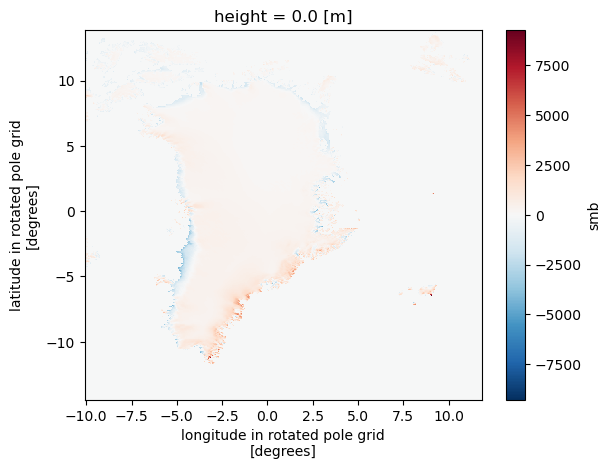

In [8]:
RACMO_smb_yearly_mean_sel.plot();

In [9]:
# Save the averaged SMB field as netcdf file
racmo_rlat = RACMO_smb_yearly_mean_sel.rlat.values
racmo_rlon = RACMO_smb_yearly_mean_sel.rlon.values
df = xr.DataArray(RACMO_smb_yearly_mean_sel.values, dims=['rlat','rlon'], coords=[('rlat', racmo_rlat),('rlon', racmo_rlon)], name='SMB', attrs=dict(longname='RACMO mean SMB averaged over 1975-2014', units='mm/yr'))
df.to_netcdf(home_dir+'2023-GrIS-melt-causality/data/RACMO/RACMO_smb_yearly_mean_1975_2014.nc')

In [10]:
# Select grid points that have <0 smb
fill_value = RACMO_smb_yearly_mean_sel[0,0].values
RACMO_ablation_mask_sel = xr.where(RACMO_smb_yearly_mean_sel == fill_value, np.NaN, RACMO_smb_yearly_mean_sel)
RACMO_ablation_mask_sel = xr.where(RACMO_ablation_mask_sel < 0, 1, 0)  #

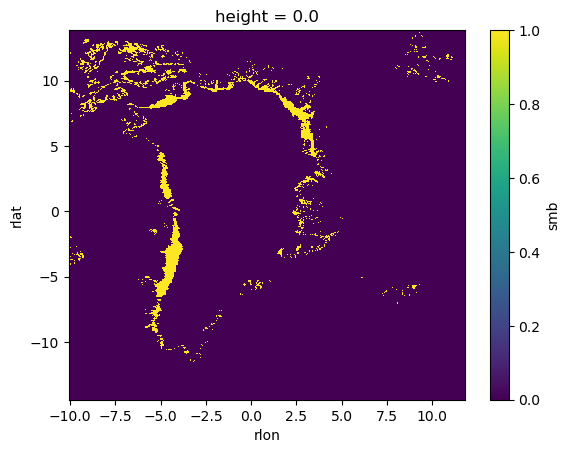

In [12]:
RACMO_ablation_mask_sel.plot();

### Mask

#### RACMO grid

In [13]:
racmo_landmask = xr.open_dataset(home_dir+'data/RACMO/RACMO2.3p2_FGRN055/FGRN055_Masks.nc')['LSM_GR'] #Land sea mask (land:1, sea:0)
#racmo_icemask = xr.open_dataset(home_dir+'data/RACMO/RACMO2.3p2_FGRN055/FGRN055_Masks.nc')['Icemask_GR'] #Ice mask(ice sheet + ice caps)
racmo_icemask = xr.open_dataset(home_dir+'data/RACMO/RACMO2.3p2_FGRN055/FGRN055_Masks.nc')['Promicemask'] #Ice mask(only ice sheet)
racmo_icemask = xr.where(racmo_icemask==4, 1, 0)
racmo_GrIS_mask = racmo_landmask * racmo_icemask # [only 0 or 1]

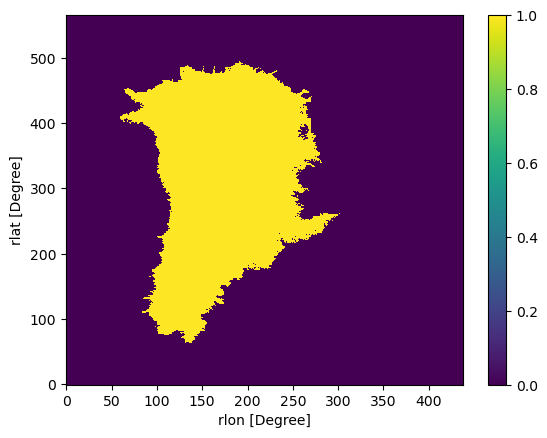

In [14]:
racmo_GrIS_mask.plot();

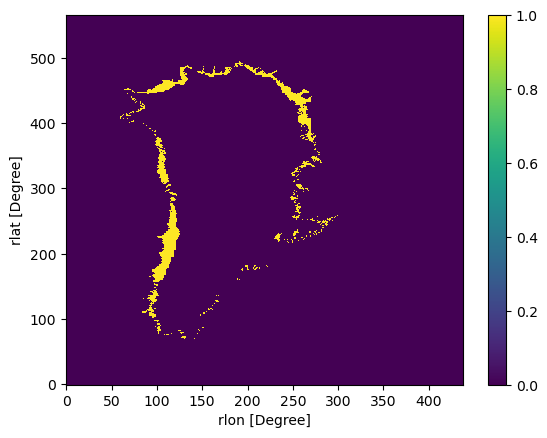

In [15]:
racmo_GrIS_ablation_mask = racmo_GrIS_mask * RACMO_ablation_mask_sel.values
racmo_GrIS_ablation_mask.plot();

In [16]:
# Save ablation mask as netcdf file
df = xr.DataArray(racmo_GrIS_ablation_mask.where(racmo_GrIS_ablation_mask>0).values, dims=['rlat','rlon'], coords=[('rlat', racmo_rlat),('rlon', racmo_rlon)], name='SMB', attrs=dict(longname='RACMO mean ablation mask over 1985-2014', units=''))
df.to_netcdf(home_dir+'2023-GrIS-melt-causality/data/RACMO/RACMO_ablation_mask_yearly_mean_1975_2014.nc')

## Calculate

In [17]:
# Melt
days_in_month = RACMO_melt_monthly_sel.time.dt.days_in_month # [day]
RACMO_GrIS_melt_monthly_sel = (RACMO_melt_monthly_sel * racmo_GrIS_ablation_mask.values * racmo_area.values).sum(dim=['rlon','rlat']) / 1e3 # [m3/month]
RACMO_GrIS_melt_monthly_sel = RACMO_GrIS_melt_monthly_sel * 1e3 / days_in_month.values # [kg/day]

In [18]:
# SEB
RACMO_GrIS_SWn_monthly_sel = (RACMO_SWn_monthly_sel * racmo_GrIS_ablation_mask.values * racmo_area.values).sum(dim=['rlon','rlat']) / (racmo_GrIS_ablation_mask * racmo_area.values).sum(dim=['rlon','rlat'])
RACMO_GrIS_LWn_monthly_sel = (RACMO_LWn_monthly_sel * racmo_GrIS_ablation_mask.values * racmo_area.values).sum(dim=['rlon','rlat']) / (racmo_GrIS_ablation_mask * racmo_area.values).sum(dim=['rlon','rlat'])
RACMO_GrIS_SH_monthly_sel = (RACMO_SH_monthly_sel * racmo_GrIS_ablation_mask.values * racmo_area.values).sum(dim=['rlon','rlat']) / (racmo_GrIS_ablation_mask * racmo_area.values).sum(dim=['rlon','rlat'])
RACMO_GrIS_LH_monthly_sel = (RACMO_LH_monthly_sel * racmo_GrIS_ablation_mask.values * racmo_area.values).sum(dim=['rlon','rlat']) / (racmo_GrIS_ablation_mask * racmo_area.values).sum(dim=['rlon','rlat'])

## Data pre-processing

In [74]:
def process_prepare_pcmci(int_vars,
                          remove_seasonal_cycle=False,
                          add_mask=True,
                          mask_period=[5, 6, 7],
                          detrend_by_month=True,
                          divide_by_std = False,
                          smooth_width_years=15):

    # Stack arrays in sequence vertically (row wise)
    data = np.vstack((
        int_vars['Melt'].values,
        int_vars['SWn'].values,
        int_vars['LWn'].values,
        int_vars['SH'].values,
        int_vars['LH'].values,
    )).T
    T, N = data.shape

    # Variable names used throughout
    global var_names
    var_names = ['Melt', 'SWn', 'LWn', 'SH', 'LH']

    cycle_length = 12  # monthly data

    # ---- 1) Detrending (global OR month-wise) ----
    if detrend_by_month:
        # Month-wise detrending: smooth each calendar-month subseries separately
        smoothdata_here = np.full_like(data, np.nan, dtype=float)
        data_here       = np.full_like(data, np.nan, dtype=float)

        for m in range(cycle_length):  # m=0..11
            idx = np.arange(m, T, cycle_length)   # all samples for month m
            sub = np.copy(data[idx, :])           # (n_years, N)

            if sub.shape[0] < 3:
                # too short to smooth meaningfully
                smooth_sub = np.zeros_like(sub)
                resid_sub  = sub
            else:
                # For month-subseries sampled yearly, 15-year smoothing => smooth_width=15
                smooth_sub = pp.smooth(np.copy(sub), smooth_width=smooth_width_years,
                                       kernel='gaussian', residuals=False)
                resid_sub  = pp.smooth(np.copy(sub), smooth_width=smooth_width_years,
                                       kernel='gaussian', residuals=True)

            smoothdata_here[idx, :] = smooth_sub
            data_here[idx, :]       = resid_sub

    else:
        # Original global detrending: 15 years * 12 months
        smooth_width = smooth_width_years * cycle_length
        smoothdata_here = pp.smooth(np.copy(data), smooth_width=smooth_width,
                                    kernel='gaussian', residuals=False)
        data_here = pp.smooth(np.copy(data), smooth_width=smooth_width,
                              kernel='gaussian', residuals=True)

    # ---- 2) Remove seasonal mean and divide by seasonal standard deviation ----
    seasonal_cycle = anomalize(np.copy(data_here), cycle_length=cycle_length, return_cycle=True)
    smoothdata_here = smoothdata_here + seasonal_cycle

    if remove_seasonal_cycle:
        data_here = anomalize(data_here, cycle_length=cycle_length, divide_by_std=divide_by_std)

    # ---- 3) Construct mask (select only JJA at time t; mask_type='y') ----
    if add_mask:
        mask = np.ones(data.shape, dtype='bool')
        for i in mask_period:
            mask[i::cycle_length, :] = False
    else:
        mask = None

    # ---- 4) Tigramite DataFrame + PCMCI ----
    dataframe = pp.DataFrame(data_here, mask=mask, var_names=var_names, missing_flag=999.)

    robustparcorr = RobustParCorr(significance='analytic', mask_type='y')
    pcmci = PCMCI(
        dataframe=dataframe,
        cond_ind_test=robustparcorr,
        verbosity=0
    )

    return pcmci

In [21]:
time = np.arange('1975-01', '2015-01', dtype='datetime64[M]')  # monthly time steps

# --- Create xarray Dataset ---
ds = xr.Dataset(
    {
        "Melt": (("time",), RACMO_GrIS_melt_monthly_sel.values/1e12),  # [Gt/day]
        "SWn": (("time",), RACMO_GrIS_SWn_monthly_sel.values),  # [W/m2]
        "LWn": (("time",), RACMO_GrIS_LWn_monthly_sel.values),
        "SH": (("time",), RACMO_GrIS_SH_monthly_sel.values),
        "LH": (("time",), RACMO_GrIS_LH_monthly_sel.values),
    },
    coords={"time": time},
)

# --- Save to NetCDF file ---
ds.to_netcdf("RACMO_GrIS_ablation_monthly_vars_1975_2014_mask_1975_2014.nc")

In [75]:
RACMO_GrIS_vars_monthly_1975_2014 = xr.open_dataset(home_dir+'2023-GrIS-melt-causality/RACMO/RACMO_GrIS_ablation_monthly_vars_1975_2014_mask_1975_2014.nc')
#RACMO_GrIS_melt_monthly_1985_2014 = RACMO_GrIS_vars_monthly_1985_2014.Melt
#RACMO_GrIS_SWn_monthly_1985_2014 = RACMO_GrIS_vars_monthly_1985_2014.SWn
#RACMO_GrIS_LWn_monthly_1985_2014 = RACMO_GrIS_vars_monthly_1985_2014.LWn
#RACMO_GrIS_SH_monthly_1985_2014 = RACMO_GrIS_vars_monthly_1985_2014.SH
#RACMO_GrIS_LH_monthly_1985_2014 = RACMO_GrIS_vars_monthly_1985_2014.LH

In [25]:
pcmci = process_prepare_pcmci(RACMO_GrIS_vars_monthly_1975_2014,
                          remove_seasonal_cycle=True,
                          add_mask=True,
                          mask_period=[5, 6, 7],
                          detrend_by_month=True,
                          smooth_width_years=15)

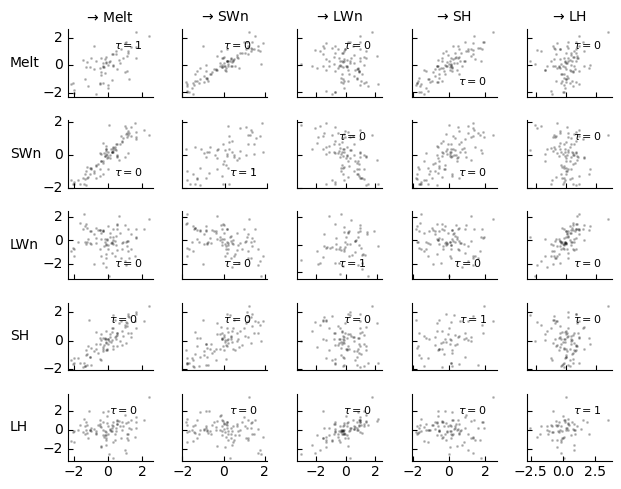

In [11]:
matrix_lags = None #np.argmax(np.abs(correlations), axis=2)
#matrix_lags = np.argmax(np.abs(correlations), axis=2)

# Standardize data to make it comparable
data_smooth_here = deepcopy(data_here)
mean, std = pp.weighted_avg_and_std(data_smooth_here, axis=0, weights=(mask==False))
data_smooth_here -= mean
data_smooth_here /= std

dataframe_here = pp.DataFrame(data_smooth_here, mask=mask, var_names=var_names)

tp.plot_scatterplots(dataframe=dataframe_here, add_scatterplot_args={'matrix_lags':matrix_lags}); plt.show()

(The diagonal panels show the lag-zero scatter plots of variables with itself here.)

Next, we investigate kernel density estimates of the joint and marginal (diagonal panels) densities.

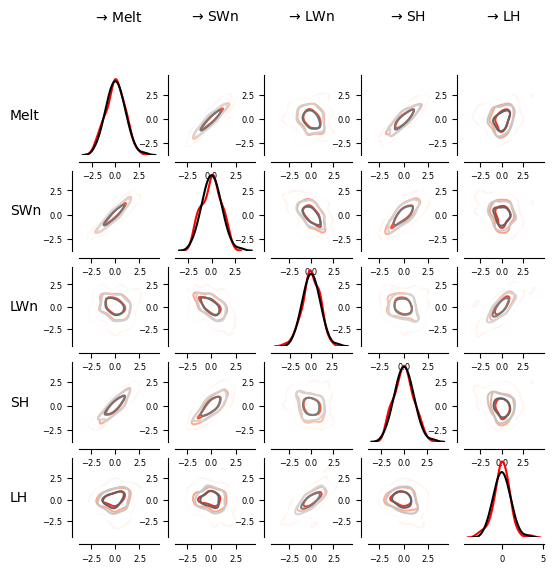

In [12]:
matrix = tp.setup_density_matrix(N=N, 
        var_names=dataframe_here.var_names, **{
        'figsize':(6, 6), 
        'tick_label_size':6,
        'label_space_left':0.18})

# Now transform data to normal marginals
data_normal = deepcopy(data_here)
data_normal = pp.trafo2normal(data_here, mask=mask)
dataframe_normal = pp.DataFrame(data_normal, mask=mask, var_names=var_names)

matrix.add_densityplot(dataframe=dataframe_here,
    matrix_lags=matrix_lags, label_color='red',
    snskdeplot_args = {'cmap':'Reds', 'alpha':1., 'levels':4})

matrix.add_densityplot(dataframe=dataframe_normal,
    matrix_lags=matrix_lags, label_color='black',
    snskdeplot_args = {'cmap':'Greys', 'alpha':1., 'levels':4})

The marginal densities (red) are slightly non-normal. By transforming the variables such that their marginals are normally distributed, the resulting joint densities are reasonably linear. Here there are only small differences, but these can nevertheless affect the conditional independence tests. Therefore, conditional independence tests in PCMCI+ should be undertaken with a robust partial correlation (``RobustParCorr``) here, which is a variant of partial correlation where the variables are first transformed to normally-distributed marginals. With ``significance='analytic'`` the null distribution is assumed to be Student's $t$. 

Next, it's a good idea to plot the lagged unconditional dependencies, e.g., the lagged correlations using the ``RobustParCorr`` class. This can help to identify which maximal time lag ``tau_max`` to choose in the causal algorithm.
 
To this end we initialize the ``PCMCI`` method with  ``dataframe``, and ``RobustParCorr`` as a ``cond_ind_test``. 

In [13]:
robustparcorr = RobustParCorr(significance='analytic', mask_type='y')
pcmci = PCMCI(
    dataframe=dataframe,
    cond_ind_test=robustparcorr,
    verbosity=1)

Before running PCMCIplus, it's a good idea to run and plot the function ``run_bivci``, which implements a bivariate, lagged conditional independence test (similar to bivariate Granger causality, but lag-specific). This can help to identify which maximal time lag ``tau_max`` to choose. Another option would be to plot ``get_lagged_dependencies``, but large autocorrelation will inflate lag peaks (see https://journals.ametsoc.org/doi/full/10.1175/JCLI-D-13-00159.1) and ``run_bivci`` at least conditions out some part of the autocorrelation.


##
## Estimating lagged dependencies 
##

Parameters:

independence test = robust_par_corr
tau_min = 0
tau_max = 20


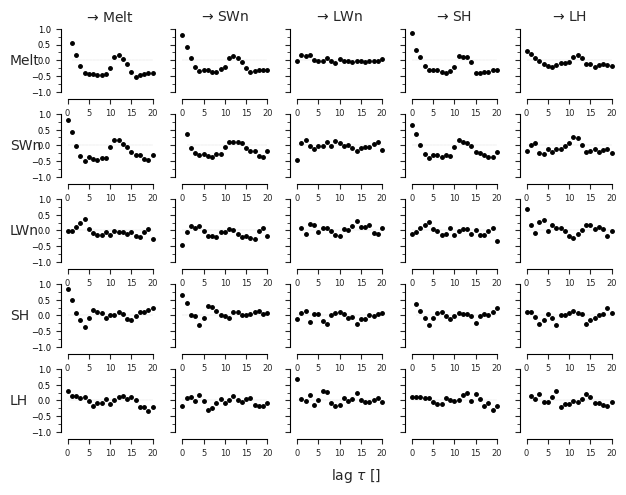

In [14]:
correlations = pcmci.get_lagged_dependencies(tau_max=20, val_only=True)['val_matrix']
#correlations = pcmci.run_bivci(tau_max=20, val_only=True)['val_matrix']
lag_func_matrix = tp.plot_lagfuncs(val_matrix=correlations, setup_args={'var_names':var_names, 
                                    'x_base':5, 'y_base':.5}); plt.show()

## PCMCI+ causal discovery

Here, we choose ``tau_max=12`` for PCMCI. The other main parameter is ``pc_alpha`` which sets the significance level in the condition-selection step. The parameter ``alpha_level=0.1`` indicates that we threshold the resulting p-value matrix at this significance level to obtain the graph. 

In [26]:
pcmci.verbosity = 0
results = pcmci.run_pcmciplus(tau_min=0, tau_max=12, pc_alpha=0.1, contemp_collider_rule='conservative') #reset_lagged_links=True adds more links to piControl case, not 4xext
#results = pcmci.run_pcmciplus(tau_min=0, tau_max=15, pc_alpha=0.01)

In [28]:
#q_matrix = pcmci.get_corrected_pvalues(p_matrix=results['p_matrix'], tau_max=15, fdr_method='fdr_bh')
q_matrix = pcmci.get_corrected_pvalues(p_matrix=results['p_matrix'], fdr_method='fdr_bh', exclude_contemporaneous=False)
pcmci.print_significant_links(
        p_matrix = q_matrix,
        val_matrix = results['val_matrix'],
        alpha_level = 0.01)
graph = pcmci.get_graph_from_pmatrix(p_matrix=q_matrix, alpha_level=0.01, 
            tau_min=0, tau_max=15, link_assumptions=None)
results['graph'] = graph


## Significant links at alpha = 0.01:

    Variable Melt has 2 link(s):
        (SWn  0): pval = 0.00000 | val =  0.804
        (SH  0): pval = 0.00000 | val =  0.547

    Variable SWn has 2 link(s):
        (Melt  0): pval = 0.00000 | val =  0.804
        (LWn  0): pval = 0.00000 | val = -0.404

    Variable LWn has 3 link(s):
        (LH  0): pval = 0.00000 | val =  0.604
        (SWn  0): pval = 0.00000 | val = -0.404
        (SH -3): pval = 0.00981 | val = -0.250

    Variable SH has 1 link(s):
        (Melt  0): pval = 0.00000 | val =  0.547

    Variable LH has 1 link(s):
        (LWn  0): pval = 0.00000 | val =  0.604


### Further relevant methodological tutorials

The tutorial ``assumptions`` explains the underlying assumptions of causal discovery and how violations of these affect the methods.

Here we showcased ``run_pcmci`` which assumes no contemporaneous causal links. Have a look at ``run_pcmciplus`` in the corresponding tutorial ``pcmciplus`` for a method that can also detect (and account for confounding due to) contemporaneous causal links.

The tutorial ``latent-pcmci`` explains the class ``LPCMCI`` that can be used if you want to allow for hidden confounding in addition to contemporaneous links.

the tutorial ``tigramite_tutorial_jpcmciplus`` shows how to utilize multiple datasets to learn joint causal graphs and overcome some kinds of hidden confounding.

The tutorial ``conditional_independence_tests`` gives an overview of all conditional independence tests available in tigramite, including those for nonlinear and categorical variables.

The tutorial ``tigramite_tutorial_bootstrap_aggregation`` shows how bootstrap can be used for more robust causal graphs and confidence estimation of links.

The tutorial ``pcmci_fullci`` compares PCMCI with alternative estimators of vector-autoregressive models.

## Plotting

Tigramite offers several plotting options: The lag function matrix (as shown above), the time series graph, and the process graph which aggregates the information in the time series graph. Both take as arguments the ``graph`` array and optionally the ``val_matrix`` and further link attributes.

In the process graph, the node color denotes the auto-MCI value and the link colors the cross-MCI value. If links occur at multiple lags between two variables, the link color denotes the strongest one and the label lists all significant lags in order of their strength. Additionally, setting ``show_autodependency_lags=True`` will display the significant auto dependencies below the respective node labels.

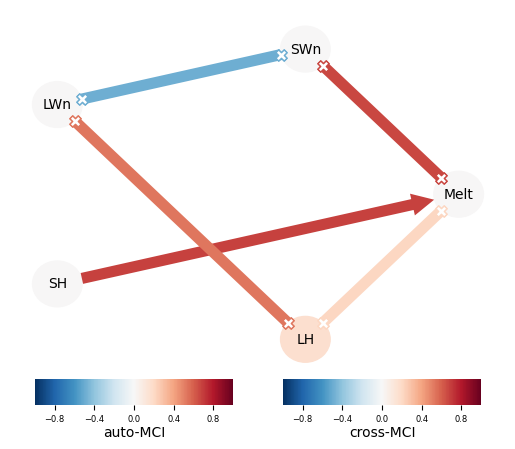

In [27]:
# without pcmci+ false-discovery rate contral
tp.plot_graph(
    val_matrix=results['val_matrix'],
    graph=results['graph'],
    var_names=['Melt', 'SWn', 'LWn', 'SH', 'LH'],
    link_colorbar_label='cross-MCI',
    node_colorbar_label='auto-MCI',
    ); #plt.show()

plot_dir = home_dir+'2023-GrIS-melt-causality/plot/RACMO/clean_mask/1975_2014/'
plt.savefig(plot_dir+'graph_pcmciplus_melt_RACMO_SEB_RACMO_noGHF_realJJA_GrIS_ablation_1975_2014_conservative_nofdrc_robustparcorr_rmmontrend_taumax12_alpha01_clean.png', dpi = 300, bbox_inches = 'tight', facecolor='w', transparent = False)

## Bootstrap

### tau_max = 12

In [76]:
pcmci = process_prepare_pcmci(RACMO_GrIS_vars_monthly_1975_2014,
                          remove_seasonal_cycle=True,
                          add_mask=True,
                          mask_period=[5, 6, 7],
                          detrend_by_month=True,
                          divide_by_std=True,
                          smooth_width_years=15)

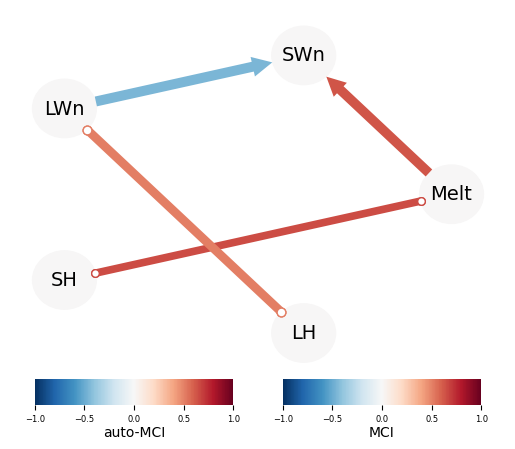

In [77]:
# alpha = 0.01
pc_alpha_bootstrap = 0.01
boot_samples = 100
tau_max = 12

# The block-length of the bootstrap can optionally be used to better deal with autocorrelation, 
# but its effect was not yet evaluated.
boot_blocklength = 12

## Create PCMCI object to call run_bootstrap_of
#pcmci = PCMCI(dataframe=dataframe,
#        cond_ind_test=robustparcorr,
#        verbosity=0,
#        )

# Call bootstrap for the chosen method (here 'run_pcmciplus') and pass method arguments  
results = pcmci.run_bootstrap_of(
        method='run_pcmciplus', 
        method_args={'tau_max':tau_max, 'pc_alpha':pc_alpha_bootstrap, 'contemp_collider_rule':'conservative'}, 
        boot_samples=boot_samples,
        boot_blocklength=boot_blocklength,
        seed=123)

# Output graph, link frequencies (confidence measure), and mean test statistic values (val_mat)
boot_linkfreq = results['summary_results']['link_frequency']
boot_graph = results['summary_results']['most_frequent_links']
val_mat = results['summary_results']['val_matrix_mean'] # mean of all graphs?

# Plot
tp.plot_graph(
    graph = boot_graph,
    val_matrix= val_mat,
    link_width = boot_linkfreq,
    var_names=var_names,
    node_size=0.4,
    node_label_size=14,
    node_ticks=0.5,
    edge_ticks=0.5,
    link_label_fontsize=14,
    arrow_linewidth=10.0,
    );

plot_dir = home_dir+'2023-GrIS-melt-causality/plot/RACMO/clean_mask/1975_2014/'
plt.savefig(plot_dir+'graph_pcmciplus_bootstrap_melt_RACMO_SEB_RACMO_noGHF_realJJA_GrIS_ablation_seasonality_1975_2014_conservative_nofdrc_robustparcorr_rmmontrend_maxtau'+str(tau_max)+'_alpha'+str(pc_alpha_bootstrap)+'_bbl'+str(boot_blocklength)+'_clean.png', dpi=300, bbox_inches='tight', facecolor='w', transparent=False)

##### without seasonal cycle, max_lag=12, pc_alpha=0.025

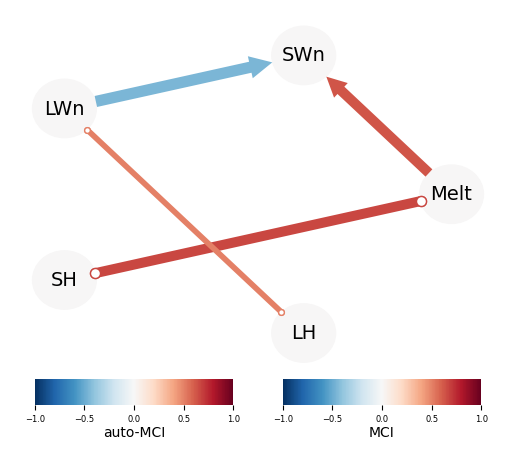

In [78]:
# alpha = 0.025
pc_alpha_bootstrap = 0.025
boot_samples = 100
tau_max = 12

# The block-length of the bootstrap can optionally be used to better deal with autocorrelation, 
# but its effect was not yet evaluated.
boot_blocklength = 12

## Create PCMCI object to call run_bootstrap_of
#pcmci = PCMCI(dataframe=dataframe,
#        cond_ind_test=robustparcorr,
#        verbosity=0,
#        )

# Call bootstrap for the chosen method (here 'run_pcmciplus') and pass method arguments  
results = pcmci.run_bootstrap_of(
        method='run_pcmciplus', 
        method_args={'tau_max':tau_max, 'pc_alpha':pc_alpha_bootstrap, 'contemp_collider_rule':'conservative'}, 
        boot_samples=boot_samples,
        boot_blocklength=boot_blocklength,
        seed=123)

# Output graph, link frequencies (confidence measure), and mean test statistic values (val_mat)
boot_linkfreq = results['summary_results']['link_frequency']
boot_graph = results['summary_results']['most_frequent_links']
val_mat = results['summary_results']['val_matrix_mean'] # mean of all graphs?

# Plot
tp.plot_graph(
    graph = boot_graph,
    val_matrix= val_mat,
    link_width = boot_linkfreq,
    var_names=var_names,
    node_size=0.4,
    node_label_size=14,
    node_ticks=0.5,
    edge_ticks=0.5,
    link_label_fontsize=14,
    arrow_linewidth=10.0,
    );

plot_dir = home_dir+'2023-GrIS-melt-causality/plot/RACMO/clean_mask/1975_2014/'
plt.savefig(plot_dir+'graph_pcmciplus_bootstrap_melt_RACMO_SEB_RACMO_noGHF_realJJA_GrIS_ablation_seasonality_1975_2014_conservative_nofdrc_robustparcorr_rmmontrend_maxtau'+str(tau_max)+'_alpha'+str(pc_alpha_bootstrap)+'_bbl'+str(boot_blocklength)+'_clean.png', dpi=300, bbox_inches='tight', facecolor='w', transparent=False)

In [79]:
#The links can also be exported to a csv file:
tp.write_csv(
    val_matrix=val_mat,
    graph=boot_graph,
    var_names=var_names,
    link_width=boot_linkfreq,
    save_name=home_dir+'2023-GrIS-melt-causality/data/RACMO/graph_pcmciplus_bootstrap_melt_RACMO_SEB_RACMO_noGHF_realJJA_GrIS_ablation_seasonality_1975_2014_conservative_nofdrc_robustparcorr_rmmontrend_maxtau'+str(tau_max)+'_alpha'+str(pc_alpha_bootstrap)+'_bbl'+str(boot_blocklength)+'_clean.csv',
    digits=5,
)

In [80]:
save_name = home_dir+'2023-GrIS-melt-causality/data/RACMO/graph_pcmciplus_bootstrap_melt_RACMO_SEB_RACMO_noGHF_realJJA_GrIS_ablation_seasonality_1975_2014_conservative_nofdrc_robustparcorr_rmmontrend_maxtau'+str(tau_max)+'_alpha'+str(pc_alpha_bootstrap)+'_bbl'+str(boot_blocklength)+'_clean.csv'
pd.read_csv(save_name)

,Variable i,Variable j,Time lag of i,Link type i --- j,Link value,Link width
0,Melt,SWn,0,-->,0.62691,0.72
1,Melt,SH,0,o-o,0.66511,0.72
2,SWn,LWn,0,<--,-0.45915,0.81
3,LWn,LH,0,o-o,0.50420,0.41


In [81]:
# Save for plotting (since the format saved by tp.write_csv is hard to use)
save_name = home_dir+'2023-GrIS-melt-causality/data/RACMO/graph_pcmciplus_bootstrap_melt_RACMO_SEB_RACMO_noGHF_realJJA_GrIS_ablation_seasonality_1975_2014_conservative_nofdrc_robustparcorr_rmmontrend_maxtau'+str(tau_max)+'_alpha'+str(pc_alpha_bootstrap)+'_bbl'+str(boot_blocklength)+'_clean_forplot.npz'

np.savez(save_name,
         val_matrix=val_mat,
         graph=boot_graph,
         link_width=boot_linkfreq,
         var_names=var_names)

##### without seasonal cycle, max_lag=12, pc_alpha=0.05

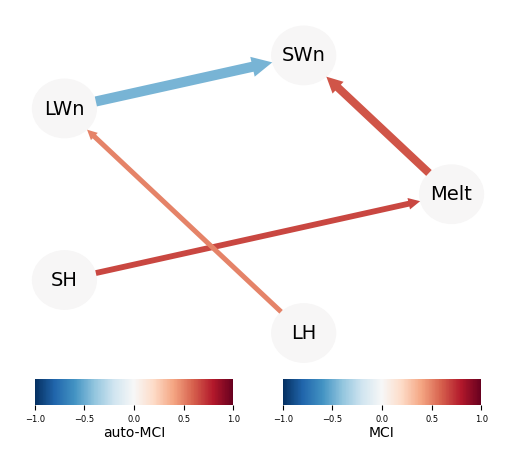

In [82]:
# alpha = 0.05
pc_alpha_bootstrap = 0.05
boot_samples = 100
tau_max = 12

# The block-length of the bootstrap can optionally be used to better deal with autocorrelation, 
# but its effect was not yet evaluated.
boot_blocklength = 12

## Create PCMCI object to call run_bootstrap_of
#pcmci = PCMCI(dataframe=dataframe,
#        cond_ind_test=robustparcorr,
#        verbosity=0,
#        )

# Call bootstrap for the chosen method (here 'run_pcmciplus') and pass method arguments  
results = pcmci.run_bootstrap_of(
        method='run_pcmciplus', 
        method_args={'tau_max':tau_max, 'pc_alpha':pc_alpha_bootstrap, 'contemp_collider_rule':'conservative'}, 
        boot_samples=boot_samples,
        boot_blocklength=boot_blocklength,
        seed=123)

# Output graph, link frequencies (confidence measure), and mean test statistic values (val_mat)
boot_linkfreq = results['summary_results']['link_frequency']
boot_graph = results['summary_results']['most_frequent_links']
val_mat = results['summary_results']['val_matrix_mean'] # mean of all graphs?

# Plot
tp.plot_graph(
    graph = boot_graph,
    val_matrix= val_mat,
    link_width = boot_linkfreq,
    var_names=var_names,
    node_size=0.4,
    node_label_size=14,
    node_ticks=0.5,
    edge_ticks=0.5,
    link_label_fontsize=14,
    arrow_linewidth=10.0,
    );

plot_dir = home_dir+'2023-GrIS-melt-causality/plot/RACMO/clean_mask/1975_2014/'
plt.savefig(plot_dir+'graph_pcmciplus_bootstrap_melt_RACMO_SEB_RACMO_noGHF_realJJA_GrIS_ablation_seasonality_1975_2014_conservative_nofdrc_robustparcorr_rmmontrend_maxtau'+str(tau_max)+'_alpha'+str(pc_alpha_bootstrap)+'_bbl'+str(boot_blocklength)+'_clean.png', dpi=300, bbox_inches='tight', facecolor='w', transparent=False)

In [83]:
#The links can also be exported to a csv file:
tp.write_csv(
    val_matrix=val_mat,
    graph=boot_graph,
    var_names=var_names,
    link_width=boot_linkfreq,
    save_name=home_dir+'2023-GrIS-melt-causality/data/RACMO/graph_pcmciplus_bootstrap_melt_RACMO_SEB_RACMO_noGHF_realJJA_GrIS_ablation_seasonality_1975_2014_conservative_nofdrc_robustparcorr_rmmontrend_maxtau'+str(tau_max)+'_alpha'+str(pc_alpha_bootstrap)+'_bbl'+str(boot_blocklength)+'_clean.csv',
    digits=5,
)

In [84]:
save_name = home_dir+'2023-GrIS-melt-causality/data/RACMO/graph_pcmciplus_bootstrap_melt_RACMO_SEB_RACMO_noGHF_realJJA_GrIS_ablation_seasonality_1975_2014_conservative_nofdrc_robustparcorr_rmmontrend_maxtau'+str(tau_max)+'_alpha'+str(pc_alpha_bootstrap)+'_bbl'+str(boot_blocklength)+'_clean.csv'
pd.read_csv(save_name)

,Variable i,Variable j,Time lag of i,Link type i --- j,Link value,Link width
0,Melt,SWn,0,-->,0.62574,0.58
1,Melt,SH,0,<--,0.66813,0.42
2,SWn,LWn,0,<--,-0.46794,0.73
3,LWn,LH,0,<--,0.49733,0.36


In [85]:
# Save for plotting (since the format saved by tp.write_csv is hard to use)
save_name = home_dir+'2023-GrIS-melt-causality/data/RACMO/graph_pcmciplus_bootstrap_melt_RACMO_SEB_RACMO_noGHF_realJJA_GrIS_ablation_seasonality_1975_2014_conservative_nofdrc_robustparcorr_rmmontrend_maxtau'+str(tau_max)+'_alpha'+str(pc_alpha_bootstrap)+'_bbl'+str(boot_blocklength)+'_clean_forplot.npz'

np.savez(save_name,
         val_matrix=val_mat,
         graph=boot_graph,
         link_width=boot_linkfreq,
         var_names=var_names)

##### without seasonal cycle, max_lag=12, pc_alpha=0.1

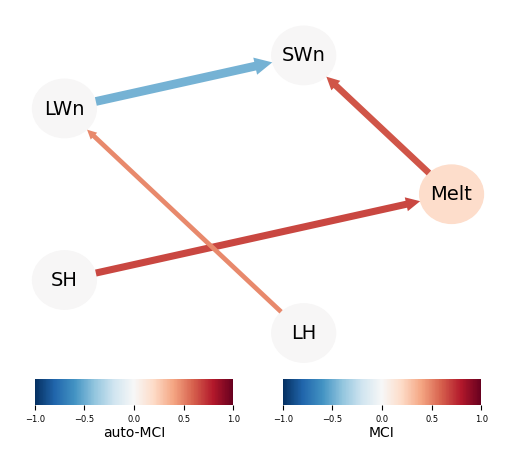

In [86]:
# alpha = 0.1
pc_alpha_bootstrap = 0.1
boot_samples = 100
tau_max = 12

# The block-length of the bootstrap can optionally be used to better deal with autocorrelation, 
# but its effect was not yet evaluated.
boot_blocklength = 12

## Create PCMCI object to call run_bootstrap_of
#pcmci = PCMCI(dataframe=dataframe,
#        cond_ind_test=robustparcorr,
#        verbosity=0,
#        )

# Call bootstrap for the chosen method (here 'run_pcmciplus') and pass method arguments  
results = pcmci.run_bootstrap_of(
        method='run_pcmciplus', 
        method_args={'tau_max':tau_max, 'pc_alpha':pc_alpha_bootstrap, 'contemp_collider_rule':'conservative'}, 
        boot_samples=boot_samples,
        boot_blocklength=boot_blocklength,
        seed=123)

# Output graph, link frequencies (confidence measure), and mean test statistic values (val_mat)
boot_linkfreq = results['summary_results']['link_frequency']
boot_graph = results['summary_results']['most_frequent_links']
val_mat = results['summary_results']['val_matrix_mean']

# Plot
tp.plot_graph(
    graph = boot_graph,
    val_matrix= val_mat,
    link_width = boot_linkfreq,
    var_names=var_names,
    node_size=0.4,
    node_label_size=14,
    node_ticks=0.5,
    edge_ticks=0.5,
    link_label_fontsize=14,
    arrow_linewidth=10.0,
    );

plot_dir = home_dir+'2023-GrIS-melt-causality/plot/RACMO/clean_mask/1975_2014/'
plt.savefig(plot_dir+'graph_pcmciplus_bootstrap_melt_RACMO_SEB_RACMO_noGHF_realJJA_GrIS_ablation_seasonality_1975_2014_conservative_nofdrc_robustparcorr_rmmontrend_maxtau'+str(tau_max)+'_alpha'+str(pc_alpha_bootstrap)+'_bbl'+str(boot_blocklength)+'_clean.png', dpi=300, bbox_inches='tight', facecolor='w', transparent=False)

In [87]:
boot_graph[0,:,:]

array([['', '-->', '', '', '', '', '', '', '', '', '', '', ''],
       ['-->', '', '', '', '', '', '', '', '', '', '', '', ''],
       ['', '', '', '', '', '', '', '', '', '', '', '', ''],
       ['<--', '', '', '', '', '', '', '', '', '', '', '', ''],
       ['', '', '', '', '', '', '', '', '', '', '', '', '']], dtype='<U3')

In [88]:
np.where(boot_graph != '', val_mat, np.NaN)[0,:,:]

array([[       nan, 0.18695049,        nan,        nan,        nan,
               nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan],
       [0.62665656,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan],
       [       nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan],
       [0.67170082,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan],
       [       nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan]])

In [34]:
results['summary_results']

{'most_frequent_links': array([[['', '', '', '', '', '', '', '', '', '', '', '', ''],
         ['-->', '', '', '', '', '', '', '', '', '', '', '', ''],
         ['', '', '', '', '', '', '', '', '', '', '', '', ''],
         ['<--', '', '-->', '', '', '', '', '', '', '', '', '', ''],
         ['', '', '', '', '', '', '', '', '', '', '', '', '']],
 
        [['<--', '', '', '', '', '', '', '', '', '', '', '', ''],
         ['', '', '', '', '', '', '', '', '', '', '', '', ''],
         ['<--', '', '', '', '', '', '', '', '', '', '', '', ''],
         ['', '', '', '', '', '', '', '', '', '', '', '', ''],
         ['', '', '', '', '', '', '', '', '', '', '', '', '']],
 
        [['', '', '', '', '', '', '', '', '', '', '', '', ''],
         ['-->', '', '', '', '', '', '', '', '', '', '', '', ''],
         ['', '', '', '', '', '', '', '', '', '', '', '', ''],
         ['', '', '', '', '', '', '', '', '', '', '', '', ''],
         ['x-x', '', '', '', '', '', '', '', '', '', '', '', '']],
 
  

In [89]:
#The links can also be exported to a csv file:
tp.write_csv(
    val_matrix=val_mat,
    graph=boot_graph,
    var_names=var_names,
    link_width=boot_linkfreq,
    save_name=home_dir+'2023-GrIS-melt-causality/data/RACMO/graph_pcmciplus_bootstrap_melt_RACMO_SEB_RACMO_noGHF_realJJA_GrIS_ablation_seasonality_1975_2014_conservative_nofdrc_robustparcorr_rmmontrend_maxtau'+str(tau_max)+'_alpha'+str(pc_alpha_bootstrap)+'_bbl'+str(boot_blocklength)+'_clean.csv',
    digits=5,
)

In [90]:
save_name = home_dir+'2023-GrIS-melt-causality/data/RACMO/graph_pcmciplus_bootstrap_melt_RACMO_SEB_RACMO_noGHF_realJJA_GrIS_ablation_seasonality_1975_2014_conservative_nofdrc_robustparcorr_rmmontrend_maxtau'+str(tau_max)+'_alpha'+str(pc_alpha_bootstrap)+'_bbl'+str(boot_blocklength)+'_clean.csv'
pd.read_csv(save_name)

,Variable i,Variable j,Time lag of i,Link type i --- j,Link value,Link width
0,Melt,Melt,1,-->,0.18695,0.58
1,Melt,SWn,0,-->,0.62666,0.47
2,Melt,SH,0,<--,0.67170,0.51
3,SWn,LWn,0,<--,-0.47007,0.63
4,LWn,LH,0,<--,0.48134,0.34


In [91]:
# Save for plotting (since the format saved by tp.write_csv is hard to use)
save_name = home_dir+'2023-GrIS-melt-causality/data/RACMO/graph_pcmciplus_bootstrap_melt_RACMO_SEB_RACMO_noGHF_realJJA_GrIS_ablation_seasonality_1975_2014_conservative_nofdrc_robustparcorr_rmmontrend_maxtau'+str(tau_max)+'_alpha'+str(pc_alpha_bootstrap)+'_bbl'+str(boot_blocklength)+'_clean_forplot.npz'

np.savez(save_name,
         val_matrix=val_mat,
         graph=boot_graph,
         link_width=boot_linkfreq,
         var_names=var_names)

##### without seasonal cycle, max_lag=12, pc_alpha=None

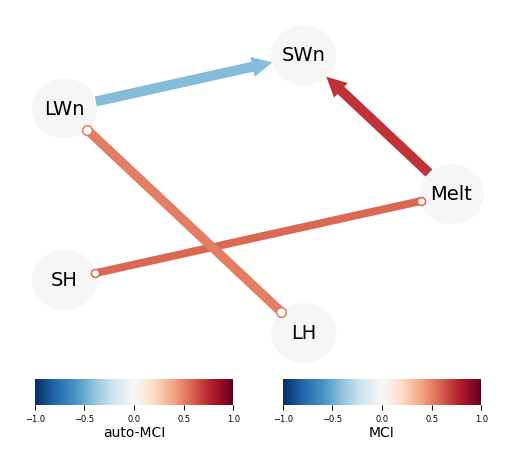

In [42]:
# alpha = None
pc_alpha_bootstrap = None
boot_samples = 100
tau_max = 12

# The block-length of the bootstrap can optionally be used to better deal with autocorrelation, 
# but its effect was not yet evaluated.
boot_blocklength = 12

## Create PCMCI object to call run_bootstrap_of
#pcmci = PCMCI(dataframe=dataframe,
#        cond_ind_test=robustparcorr,
#        verbosity=0,
#        )

# Call bootstrap for the chosen method (here 'run_pcmciplus') and pass method arguments  
results = pcmci.run_bootstrap_of(
        method='run_pcmciplus', 
        method_args={'tau_max':tau_max, 'pc_alpha':pc_alpha_bootstrap, 'contemp_collider_rule':'conservative'}, 
        boot_samples=boot_samples,
        boot_blocklength=boot_blocklength,
        seed=123)

# Output graph, link frequencies (confidence measure), and mean test statistic values (val_mat)
boot_linkfreq = results['summary_results']['link_frequency']
boot_graph = results['summary_results']['most_frequent_links']
val_mat = results['summary_results']['val_matrix_mean']

# Plot
tp.plot_graph(
    graph = boot_graph,
    val_matrix= val_mat,
    link_width = boot_linkfreq,
    var_names=var_names,
    node_size=0.4,
    node_label_size=14,
    node_ticks=0.5,
    edge_ticks=0.5,
    link_label_fontsize=14,
    arrow_linewidth=10.0,
    );

plot_dir = home_dir+'2023-GrIS-melt-causality/plot/RACMO/clean_mask/1975_2014/'
plt.savefig(plot_dir+'graph_pcmciplus_bootstrap_melt_RACMO_SEB_RACMO_noGHF_realJJA_GrIS_ablation_seasonality_1975_2014_conservative_nofdrc_robustparcorr_rmmontrend_maxtau'+str(tau_max)+'_alpha'+str(pc_alpha_bootstrap)+'_bbl'+str(boot_blocklength)+'_clean.png', dpi=300, bbox_inches='tight', facecolor='w', transparent=False)

In [43]:
#The links can also be exported to a csv file:
tp.write_csv(
    val_matrix=val_mat,
    graph=boot_graph,
    var_names=var_names,
    link_width=boot_linkfreq,
    save_name=home_dir+'2023-GrIS-melt-causality/data/RACMO/graph_pcmciplus_bootstrap_melt_RACMO_SEB_RACMO_noGHF_realJJA_GrIS_ablation_seasonality_1975_2014_conservative_nofdrc_robustparcorr_rmmontrend_maxtau'+str(tau_max)+'_alpha'+str(pc_alpha_bootstrap)+'_bbl'+str(boot_blocklength)+'_clean.csv',
    digits=5,
)

In [44]:
save_name = home_dir+'2023-GrIS-melt-causality/data/RACMO/graph_pcmciplus_bootstrap_melt_RACMO_SEB_RACMO_noGHF_realJJA_GrIS_ablation_seasonality_1975_2014_conservative_nofdrc_robustparcorr_rmmontrend_maxtau'+str(tau_max)+'_alpha'+str(pc_alpha_bootstrap)+'_bbl'+str(boot_blocklength)+'_clean.csv'
pd.read_csv(save_name)

,Variable i,Variable j,Time lag of i,Link type i --- j,Link value,Link width
0,Melt,SWn,0,-->,0.72096,0.72
1,Melt,SH,0,o-o,0.57566,0.57
2,SWn,LWn,0,<--,-0.43725,0.73
3,LWn,LH,0,o-o,0.51443,0.68


In [45]:
# Save for plotting (since the format saved by tp.write_csv is hard to use)
save_name = home_dir+'2023-GrIS-melt-causality/data/RACMO/graph_pcmciplus_bootstrap_melt_RACMO_SEB_RACMO_noGHF_realJJA_GrIS_ablation_seasonality_1975_2014_conservative_nofdrc_robustparcorr_rmmontrend_maxtau'+str(tau_max)+'_alpha'+str(pc_alpha_bootstrap)+'_bbl'+str(boot_blocklength)+'_clean_forplot.npz'

np.savez(save_name,
         val_matrix=val_mat,
         graph=boot_graph,
         link_width=boot_linkfreq,
         var_names=var_names)

### tau_max = 12, not divided by monthly std

In [46]:
pcmci = process_prepare_pcmci(RACMO_GrIS_vars_monthly_1975_2014,
                          remove_seasonal_cycle=True,
                          add_mask=True,
                          mask_period=[5, 6, 7],
                          detrend_by_month=True,
                          divide_by_std = False,
                          smooth_width_years=15)

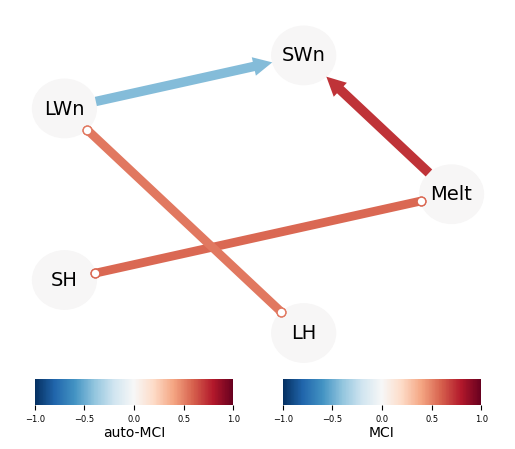

In [47]:
# alpha = 0.01
pc_alpha_bootstrap = 0.01
boot_samples = 100
tau_max = 12

# The block-length of the bootstrap can optionally be used to better deal with autocorrelation, 
# but its effect was not yet evaluated.
boot_blocklength = 12

## Create PCMCI object to call run_bootstrap_of
#pcmci = PCMCI(dataframe=dataframe,
#        cond_ind_test=robustparcorr,
#        verbosity=0,
#        )

# Call bootstrap for the chosen method (here 'run_pcmciplus') and pass method arguments  
results = pcmci.run_bootstrap_of(
        method='run_pcmciplus', 
        method_args={'tau_max':tau_max, 'pc_alpha':pc_alpha_bootstrap, 'contemp_collider_rule':'conservative'}, 
        boot_samples=boot_samples,
        boot_blocklength=boot_blocklength,
        seed=123)

# Output graph, link frequencies (confidence measure), and mean test statistic values (val_mat)
boot_linkfreq = results['summary_results']['link_frequency']
boot_graph = results['summary_results']['most_frequent_links']
val_mat = results['summary_results']['val_matrix_mean'] # mean of all graphs?

# Plot
tp.plot_graph(
    graph = boot_graph,
    val_matrix= val_mat,
    link_width = boot_linkfreq,
    var_names=var_names,
    node_size=0.4,
    node_label_size=14,
    node_ticks=0.5,
    edge_ticks=0.5,
    link_label_fontsize=14,
    arrow_linewidth=10.0,
    );

plot_dir = home_dir+'2023-GrIS-melt-causality/plot/RACMO/clean_mask/1975_2014/'
plt.savefig(plot_dir+'graph_pcmciplus_bootstrap_melt_RACMO_SEB_RACMO_noGHF_realJJA_GrIS_ablation_seasonality_1975_2014_conservative_nofdrc_robustparcorr_rmmontrend_nostd_maxtau'+str(tau_max)+'_alpha'+str(pc_alpha_bootstrap)+'_bbl'+str(boot_blocklength)+'_clean.png', dpi=300, bbox_inches='tight', facecolor='w', transparent=False)

##### without seasonal cycle, max_lag=12, pc_alpha=0.025

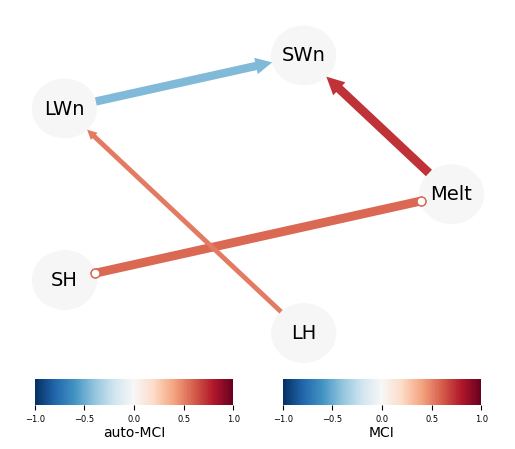

In [48]:
# alpha = 0.025
pc_alpha_bootstrap = 0.025
boot_samples = 100
tau_max = 12

# The block-length of the bootstrap can optionally be used to better deal with autocorrelation, 
# but its effect was not yet evaluated.
boot_blocklength = 12

## Create PCMCI object to call run_bootstrap_of
#pcmci = PCMCI(dataframe=dataframe,
#        cond_ind_test=robustparcorr,
#        verbosity=0,
#        )

# Call bootstrap for the chosen method (here 'run_pcmciplus') and pass method arguments  
results = pcmci.run_bootstrap_of(
        method='run_pcmciplus', 
        method_args={'tau_max':tau_max, 'pc_alpha':pc_alpha_bootstrap, 'contemp_collider_rule':'conservative'}, 
        boot_samples=boot_samples,
        boot_blocklength=boot_blocklength,
        seed=123)

# Output graph, link frequencies (confidence measure), and mean test statistic values (val_mat)
boot_linkfreq = results['summary_results']['link_frequency']
boot_graph = results['summary_results']['most_frequent_links']
val_mat = results['summary_results']['val_matrix_mean'] # mean of all graphs?

# Plot
tp.plot_graph(
    graph = boot_graph,
    val_matrix= val_mat,
    link_width = boot_linkfreq,
    var_names=var_names,
    node_size=0.4,
    node_label_size=14,
    node_ticks=0.5,
    edge_ticks=0.5,
    link_label_fontsize=14,
    arrow_linewidth=10.0,
    );

plot_dir = home_dir+'2023-GrIS-melt-causality/plot/RACMO/clean_mask/1975_2014/'
plt.savefig(plot_dir+'graph_pcmciplus_bootstrap_melt_RACMO_SEB_RACMO_noGHF_realJJA_GrIS_ablation_seasonality_1975_2014_conservative_nofdrc_robustparcorr_rmmontrend_nostd_maxtau'+str(tau_max)+'_alpha'+str(pc_alpha_bootstrap)+'_bbl'+str(boot_blocklength)+'_clean.png', dpi=300, bbox_inches='tight', facecolor='w', transparent=False)

In [49]:
#The links can also be exported to a csv file:
tp.write_csv(
    val_matrix=val_mat,
    graph=boot_graph,
    var_names=var_names,
    link_width=boot_linkfreq,
    save_name=home_dir+'2023-GrIS-melt-causality/data/RACMO/graph_pcmciplus_bootstrap_melt_RACMO_SEB_RACMO_noGHF_realJJA_GrIS_ablation_seasonality_1975_2014_conservative_nofdrc_robustparcorr_rmmontrend_nostd_maxtau'+str(tau_max)+'_alpha'+str(pc_alpha_bootstrap)+'_bbl'+str(boot_blocklength)+'_clean.csv',
    digits=5,
)

In [50]:
save_name = home_dir+'2023-GrIS-melt-causality/data/RACMO/graph_pcmciplus_bootstrap_melt_RACMO_SEB_RACMO_noGHF_realJJA_GrIS_ablation_seasonality_1975_2014_conservative_nofdrc_robustparcorr_rmmontrend_nostd_maxtau'+str(tau_max)+'_alpha'+str(pc_alpha_bootstrap)+'_bbl'+str(boot_blocklength)+'_clean.csv'
pd.read_csv(save_name)

,Variable i,Variable j,Time lag of i,Link type i --- j,Link value,Link width
0,Melt,SWn,0,-->,0.72060,0.64
1,Melt,SH,0,o-o,0.57351,0.64
2,SWn,LWn,0,<--,-0.44011,0.60
3,LWn,LH,0,<--,0.51897,0.35


In [51]:
# Save for plotting (since the format saved by tp.write_csv is hard to use)
save_name = home_dir+'2023-GrIS-melt-causality/data/RACMO/graph_pcmciplus_bootstrap_melt_RACMO_SEB_RACMO_noGHF_realJJA_GrIS_ablation_seasonality_1975_2014_conservative_nofdrc_robustparcorr_rmmontrend_nostd_maxtau'+str(tau_max)+'_alpha'+str(pc_alpha_bootstrap)+'_bbl'+str(boot_blocklength)+'_clean_forplot.npz'

np.savez(save_name,
         val_matrix=val_mat,
         graph=boot_graph,
         link_width=boot_linkfreq,
         var_names=var_names)

##### without seasonal cycle, max_lag=12, pc_alpha=0.05

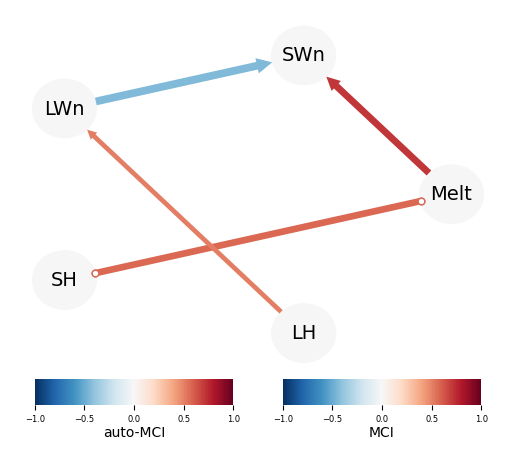

In [52]:
# alpha = 0.05
pc_alpha_bootstrap = 0.05
boot_samples = 100
tau_max = 12

# The block-length of the bootstrap can optionally be used to better deal with autocorrelation, 
# but its effect was not yet evaluated.
boot_blocklength = 12

## Create PCMCI object to call run_bootstrap_of
#pcmci = PCMCI(dataframe=dataframe,
#        cond_ind_test=robustparcorr,
#        verbosity=0,
#        )

# Call bootstrap for the chosen method (here 'run_pcmciplus') and pass method arguments  
results = pcmci.run_bootstrap_of(
        method='run_pcmciplus', 
        method_args={'tau_max':tau_max, 'pc_alpha':pc_alpha_bootstrap, 'contemp_collider_rule':'conservative'}, 
        boot_samples=boot_samples,
        boot_blocklength=boot_blocklength,
        seed=123)

# Output graph, link frequencies (confidence measure), and mean test statistic values (val_mat)
boot_linkfreq = results['summary_results']['link_frequency']
boot_graph = results['summary_results']['most_frequent_links']
val_mat = results['summary_results']['val_matrix_mean'] # mean of all graphs?

# Plot
tp.plot_graph(
    graph = boot_graph,
    val_matrix= val_mat,
    link_width = boot_linkfreq,
    var_names=var_names,
    node_size=0.4,
    node_label_size=14,
    node_ticks=0.5,
    edge_ticks=0.5,
    link_label_fontsize=14,
    arrow_linewidth=10.0,
    );

plot_dir = home_dir+'2023-GrIS-melt-causality/plot/RACMO/clean_mask/1975_2014/'
plt.savefig(plot_dir+'graph_pcmciplus_bootstrap_melt_RACMO_SEB_RACMO_noGHF_realJJA_GrIS_ablation_seasonality_1975_2014_conservative_nofdrc_robustparcorr_rmmontrend_nostd_maxtau'+str(tau_max)+'_alpha'+str(pc_alpha_bootstrap)+'_bbl'+str(boot_blocklength)+'_clean.png', dpi=300, bbox_inches='tight', facecolor='w', transparent=False)

In [53]:
#The links can also be exported to a csv file:
tp.write_csv(
    val_matrix=val_mat,
    graph=boot_graph,
    var_names=var_names,
    link_width=boot_linkfreq,
    save_name=home_dir+'2023-GrIS-melt-causality/data/RACMO/graph_pcmciplus_bootstrap_melt_RACMO_SEB_RACMO_noGHF_realJJA_GrIS_ablation_seasonality_1975_2014_conservative_nofdrc_robustparcorr_rmmontrend_nostd_maxtau'+str(tau_max)+'_alpha'+str(pc_alpha_bootstrap)+'_bbl'+str(boot_blocklength)+'_clean.csv',
    digits=5,
)

In [54]:
save_name = home_dir+'2023-GrIS-melt-causality/data/RACMO/graph_pcmciplus_bootstrap_melt_RACMO_SEB_RACMO_noGHF_realJJA_GrIS_ablation_seasonality_1975_2014_conservative_nofdrc_robustparcorr_rmmontrend_nostd_maxtau'+str(tau_max)+'_alpha'+str(pc_alpha_bootstrap)+'_bbl'+str(boot_blocklength)+'_clean.csv'
pd.read_csv(save_name)

,Variable i,Variable j,Time lag of i,Link type i --- j,Link value,Link width
0,Melt,SWn,0,-->,0.71870,0.49
1,Melt,SH,0,o-o,0.57447,0.48
2,SWn,LWn,0,<--,-0.44429,0.56
3,LWn,LH,0,<--,0.50863,0.34


In [55]:
# Save for plotting (since the format saved by tp.write_csv is hard to use)
save_name = home_dir+'2023-GrIS-melt-causality/data/RACMO/graph_pcmciplus_bootstrap_melt_RACMO_SEB_RACMO_noGHF_realJJA_GrIS_ablation_seasonality_1975_2014_conservative_nofdrc_robustparcorr_rmmontrend_nostd_maxtau'+str(tau_max)+'_alpha'+str(pc_alpha_bootstrap)+'_bbl'+str(boot_blocklength)+'_clean_forplot.npz'

np.savez(save_name,
         val_matrix=val_mat,
         graph=boot_graph,
         link_width=boot_linkfreq,
         var_names=var_names)

##### without seasonal cycle, max_lag=12, pc_alpha=0.1

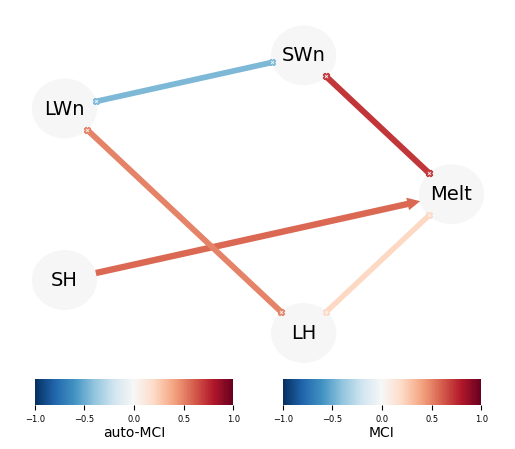

In [56]:
# alpha = 0.1
pc_alpha_bootstrap = 0.1
boot_samples = 100
tau_max = 12

# The block-length of the bootstrap can optionally be used to better deal with autocorrelation, 
# but its effect was not yet evaluated.
boot_blocklength = 12

## Create PCMCI object to call run_bootstrap_of
#pcmci = PCMCI(dataframe=dataframe,
#        cond_ind_test=robustparcorr,
#        verbosity=0,
#        )

# Call bootstrap for the chosen method (here 'run_pcmciplus') and pass method arguments  
results = pcmci.run_bootstrap_of(
        method='run_pcmciplus', 
        method_args={'tau_max':tau_max, 'pc_alpha':pc_alpha_bootstrap, 'contemp_collider_rule':'conservative'}, 
        boot_samples=boot_samples,
        boot_blocklength=boot_blocklength,
        seed=123)

# Output graph, link frequencies (confidence measure), and mean test statistic values (val_mat)
boot_linkfreq = results['summary_results']['link_frequency']
boot_graph = results['summary_results']['most_frequent_links']
val_mat = results['summary_results']['val_matrix_mean']

# Plot
tp.plot_graph(
    graph = boot_graph,
    val_matrix= val_mat,
    link_width = boot_linkfreq,
    var_names=var_names,
    node_size=0.4,
    node_label_size=14,
    node_ticks=0.5,
    edge_ticks=0.5,
    link_label_fontsize=14,
    arrow_linewidth=10.0,
    );

plot_dir = home_dir+'2023-GrIS-melt-causality/plot/RACMO/clean_mask/1975_2014/'
plt.savefig(plot_dir+'graph_pcmciplus_bootstrap_melt_RACMO_SEB_RACMO_noGHF_realJJA_GrIS_ablation_seasonality_1975_2014_conservative_nofdrc_robustparcorr_rmmontrend_nostd_maxtau'+str(tau_max)+'_alpha'+str(pc_alpha_bootstrap)+'_bbl'+str(boot_blocklength)+'_clean.png', dpi=300, bbox_inches='tight', facecolor='w', transparent=False)

In [30]:
boot_graph[0,:,:]

array([['', '', '', '', '', '', '', '', '', '', '', '', ''],
       ['-->', '', '', '', '', '', '', '', '', '', '', '', ''],
       ['', '', '', '', '', '', '', '', '', '', '', '', ''],
       ['<--', '', '-->', '', '', '', '', '', '', '', '', '', ''],
       ['', '', '', '', '', '', '', '', '', '', '', '', '']], dtype='<U3')

In [31]:
np.where(boot_graph != '', val_mat, np.NaN)[0,:,:]

array([[        nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan],
       [ 0.64472514,         nan,         nan,         nan,         nan,
                nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan],
       [        nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan],
       [ 0.62892719,         nan, -0.22507399,         nan,         nan,
                nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan],
       [        nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan]])

In [34]:
results['summary_results']

{'most_frequent_links': array([[['', '', '', '', '', '', '', '', '', '', '', '', ''],
         ['-->', '', '', '', '', '', '', '', '', '', '', '', ''],
         ['', '', '', '', '', '', '', '', '', '', '', '', ''],
         ['<--', '', '-->', '', '', '', '', '', '', '', '', '', ''],
         ['', '', '', '', '', '', '', '', '', '', '', '', '']],
 
        [['<--', '', '', '', '', '', '', '', '', '', '', '', ''],
         ['', '', '', '', '', '', '', '', '', '', '', '', ''],
         ['<--', '', '', '', '', '', '', '', '', '', '', '', ''],
         ['', '', '', '', '', '', '', '', '', '', '', '', ''],
         ['', '', '', '', '', '', '', '', '', '', '', '', '']],
 
        [['', '', '', '', '', '', '', '', '', '', '', '', ''],
         ['-->', '', '', '', '', '', '', '', '', '', '', '', ''],
         ['', '', '', '', '', '', '', '', '', '', '', '', ''],
         ['', '', '', '', '', '', '', '', '', '', '', '', ''],
         ['x-x', '', '', '', '', '', '', '', '', '', '', '', '']],
 
  

In [57]:
#The links can also be exported to a csv file:
tp.write_csv(
    val_matrix=val_mat,
    graph=boot_graph,
    var_names=var_names,
    link_width=boot_linkfreq,
    save_name=home_dir+'2023-GrIS-melt-causality/data/RACMO/graph_pcmciplus_bootstrap_melt_RACMO_SEB_RACMO_noGHF_realJJA_GrIS_ablation_seasonality_1975_2014_conservative_nofdrc_robustparcorr_rmmontrend_nostd_maxtau'+str(tau_max)+'_alpha'+str(pc_alpha_bootstrap)+'_bbl'+str(boot_blocklength)+'_clean.csv',
    digits=5,
)

In [58]:
save_name = home_dir+'2023-GrIS-melt-causality/data/RACMO/graph_pcmciplus_bootstrap_melt_RACMO_SEB_RACMO_noGHF_realJJA_GrIS_ablation_seasonality_1975_2014_conservative_nofdrc_robustparcorr_rmmontrend_nostd_maxtau'+str(tau_max)+'_alpha'+str(pc_alpha_bootstrap)+'_bbl'+str(boot_blocklength)+'_clean.csv'
pd.read_csv(save_name)

,Variable i,Variable j,Time lag of i,Link type i --- j,Link value,Link width
0,Melt,SWn,0,x-x,0.71589,0.43
1,Melt,SH,0,<--,0.57433,0.46
2,Melt,LH,0,x-x,0.20868,0.39
3,SWn,LWn,0,x-x,-0.44779,0.41
4,LWn,LH,0,x-x,0.49410,0.42


In [59]:
# Save for plotting (since the format saved by tp.write_csv is hard to use)
save_name = home_dir+'2023-GrIS-melt-causality/data/RACMO/graph_pcmciplus_bootstrap_melt_RACMO_SEB_RACMO_noGHF_realJJA_GrIS_ablation_seasonality_1975_2014_conservative_nofdrc_robustparcorr_rmmontrend_nostd_maxtau'+str(tau_max)+'_alpha'+str(pc_alpha_bootstrap)+'_bbl'+str(boot_blocklength)+'_clean_forplot.npz'

np.savez(save_name,
         val_matrix=val_mat,
         graph=boot_graph,
         link_width=boot_linkfreq,
         var_names=var_names)

##### without seasonal cycle, max_lag=12, pc_alpha=None

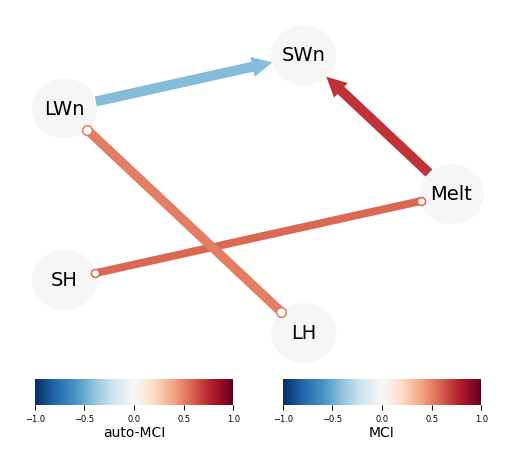

In [60]:
# alpha = None
pc_alpha_bootstrap = None
boot_samples = 100
tau_max = 12

# The block-length of the bootstrap can optionally be used to better deal with autocorrelation, 
# but its effect was not yet evaluated.
boot_blocklength = 12

## Create PCMCI object to call run_bootstrap_of
#pcmci = PCMCI(dataframe=dataframe,
#        cond_ind_test=robustparcorr,
#        verbosity=0,
#        )

# Call bootstrap for the chosen method (here 'run_pcmciplus') and pass method arguments  
results = pcmci.run_bootstrap_of(
        method='run_pcmciplus', 
        method_args={'tau_max':tau_max, 'pc_alpha':pc_alpha_bootstrap, 'contemp_collider_rule':'conservative'}, 
        boot_samples=boot_samples,
        boot_blocklength=boot_blocklength,
        seed=123)

# Output graph, link frequencies (confidence measure), and mean test statistic values (val_mat)
boot_linkfreq = results['summary_results']['link_frequency']
boot_graph = results['summary_results']['most_frequent_links']
val_mat = results['summary_results']['val_matrix_mean']

# Plot
tp.plot_graph(
    graph = boot_graph,
    val_matrix= val_mat,
    link_width = boot_linkfreq,
    var_names=var_names,
    node_size=0.4,
    node_label_size=14,
    node_ticks=0.5,
    edge_ticks=0.5,
    link_label_fontsize=14,
    arrow_linewidth=10.0,
    );

plot_dir = home_dir+'2023-GrIS-melt-causality/plot/RACMO/clean_mask/1975_2014/'
plt.savefig(plot_dir+'graph_pcmciplus_bootstrap_melt_RACMO_SEB_RACMO_noGHF_realJJA_GrIS_ablation_seasonality_1975_2014_conservative_nofdrc_robustparcorr_rmmontrend_nostd_maxtau'+str(tau_max)+'_alpha'+str(pc_alpha_bootstrap)+'_bbl'+str(boot_blocklength)+'_clean.png', dpi=300, bbox_inches='tight', facecolor='w', transparent=False)

In [61]:
#The links can also be exported to a csv file:
tp.write_csv(
    val_matrix=val_mat,
    graph=boot_graph,
    var_names=var_names,
    link_width=boot_linkfreq,
    save_name=home_dir+'2023-GrIS-melt-causality/data/RACMO/graph_pcmciplus_bootstrap_melt_RACMO_SEB_RACMO_noGHF_realJJA_GrIS_ablation_seasonality_1975_2014_conservative_nofdrc_robustparcorr_rmmontrend_nostd_maxtau'+str(tau_max)+'_alpha'+str(pc_alpha_bootstrap)+'_bbl'+str(boot_blocklength)+'_clean.csv',
    digits=5,
)

In [62]:
save_name = home_dir+'2023-GrIS-melt-causality/data/RACMO/graph_pcmciplus_bootstrap_melt_RACMO_SEB_RACMO_noGHF_realJJA_GrIS_ablation_seasonality_1975_2014_conservative_nofdrc_robustparcorr_rmmontrend_nostd_maxtau'+str(tau_max)+'_alpha'+str(pc_alpha_bootstrap)+'_bbl'+str(boot_blocklength)+'_clean.csv'
pd.read_csv(save_name)

,Variable i,Variable j,Time lag of i,Link type i --- j,Link value,Link width
0,Melt,SWn,0,-->,0.72096,0.72
1,Melt,SH,0,o-o,0.57566,0.57
2,SWn,LWn,0,<--,-0.43725,0.73
3,LWn,LH,0,o-o,0.51443,0.68


In [63]:
# Save for plotting (since the format saved by tp.write_csv is hard to use)
save_name = home_dir+'2023-GrIS-melt-causality/data/RACMO/graph_pcmciplus_bootstrap_melt_RACMO_SEB_RACMO_noGHF_realJJA_GrIS_ablation_seasonality_1975_2014_conservative_nofdrc_robustparcorr_rmmontrend_nostd_maxtau'+str(tau_max)+'_alpha'+str(pc_alpha_bootstrap)+'_bbl'+str(boot_blocklength)+'_clean_forplot.npz'

np.savez(save_name,
         val_matrix=val_mat,
         graph=boot_graph,
         link_width=boot_linkfreq,
         var_names=var_names)

##### without seasonal cycle, max_lag=12, pc_alpha=0.1, bbl=24

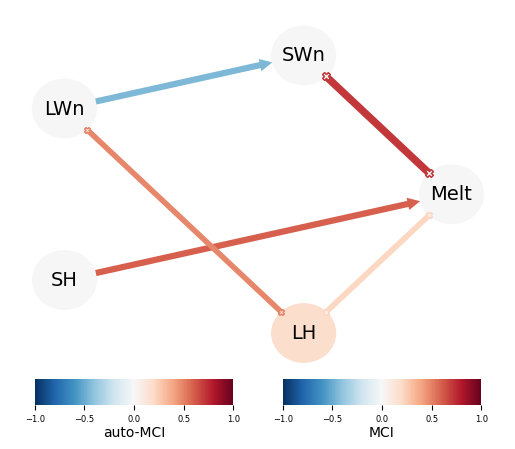

In [64]:
# alpha = 0.1
pc_alpha_bootstrap = 0.1
boot_samples = 100
tau_max = 12

# The block-length of the bootstrap can optionally be used to better deal with autocorrelation, 
# but its effect was not yet evaluated.
boot_blocklength = 24

## Create PCMCI object to call run_bootstrap_of
#pcmci = PCMCI(dataframe=dataframe,
#        cond_ind_test=robustparcorr,
#        verbosity=0,
#        )

# Call bootstrap for the chosen method (here 'run_pcmciplus') and pass method arguments  
results = pcmci.run_bootstrap_of(
        method='run_pcmciplus', 
        method_args={'tau_max':tau_max, 'pc_alpha':pc_alpha_bootstrap, 'contemp_collider_rule':'conservative'}, 
        boot_samples=boot_samples,
        boot_blocklength=boot_blocklength,
        seed=123)

# Output graph, link frequencies (confidence measure), and mean test statistic values (val_mat)
boot_linkfreq = results['summary_results']['link_frequency']
boot_graph = results['summary_results']['most_frequent_links']
val_mat = results['summary_results']['val_matrix_mean']

# Plot
tp.plot_graph(
    graph = boot_graph,
    val_matrix= val_mat,
    link_width = boot_linkfreq,
    var_names=var_names,
    node_size=0.4,
    node_label_size=14,
    node_ticks=0.5,
    edge_ticks=0.5,
    link_label_fontsize=14,
    arrow_linewidth=10.0,
    );

plot_dir = home_dir+'2023-GrIS-melt-causality/plot/RACMO/clean_mask/1975_2014/'
#plt.savefig(plot_dir+'graph_pcmciplus_bootstrap_melt_RACMO_SEB_RACMO_noGHF_realJJA_GrIS_ablation_seasonality_1965_2014_conservative_nofdrc_robustparcorr_rmmontrend_nostd_maxtau'+str(tau_max)+'_alpha'+str(pc_alpha_bootstrap)+'_bbl'+str(boot_blocklength)+'_clean.png', dpi=300, bbox_inches='tight', facecolor='w', transparent=False)

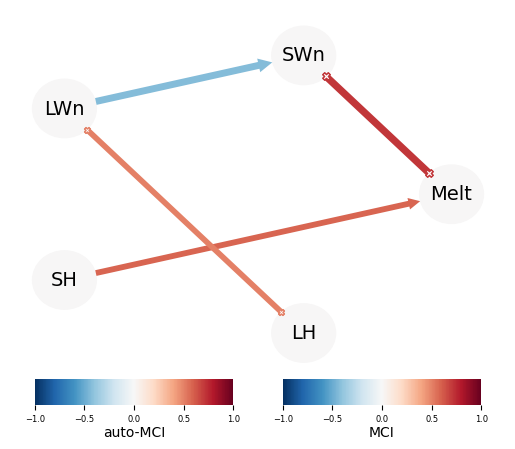

In [66]:
# alpha = 0.1
pc_alpha_bootstrap = 0.1
boot_samples = 100
tau_max = 12

# The block-length of the bootstrap can optionally be used to better deal with autocorrelation, 
# but its effect was not yet evaluated.
boot_blocklength = 18

## Create PCMCI object to call run_bootstrap_of
#pcmci = PCMCI(dataframe=dataframe,
#        cond_ind_test=robustparcorr,
#        verbosity=0,
#        )

# Call bootstrap for the chosen method (here 'run_pcmciplus') and pass method arguments  
results = pcmci.run_bootstrap_of(
        method='run_pcmciplus', 
        method_args={'tau_max':tau_max, 'pc_alpha':pc_alpha_bootstrap, 'contemp_collider_rule':'conservative'}, 
        boot_samples=boot_samples,
        boot_blocklength=boot_blocklength,
        seed=123)

# Output graph, link frequencies (confidence measure), and mean test statistic values (val_mat)
boot_linkfreq = results['summary_results']['link_frequency']
boot_graph = results['summary_results']['most_frequent_links']
val_mat = results['summary_results']['val_matrix_mean']

# Plot
tp.plot_graph(
    graph = boot_graph,
    val_matrix= val_mat,
    link_width = boot_linkfreq,
    var_names=var_names,
    node_size=0.4,
    node_label_size=14,
    node_ticks=0.5,
    edge_ticks=0.5,
    link_label_fontsize=14,
    arrow_linewidth=10.0,
    );

plot_dir = home_dir+'2023-GrIS-melt-causality/plot/RACMO/clean_mask/1975_2014/'
#plt.savefig(plot_dir+'graph_pcmciplus_bootstrap_melt_RACMO_SEB_RACMO_noGHF_realJJA_GrIS_ablation_seasonality_1965_2014_conservative_nofdrc_robustparcorr_rmmontrend_nostd_maxtau'+str(tau_max)+'_alpha'+str(pc_alpha_bootstrap)+'_bbl'+str(boot_blocklength)+'_clean.png', dpi=300, bbox_inches='tight', facecolor='w', transparent=False)

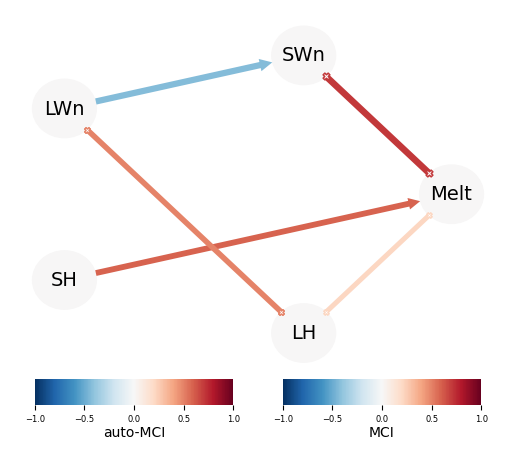

In [70]:
# alpha = 0.1
pc_alpha_bootstrap = 0.1
boot_samples = 100
tau_max = 12

# The block-length of the bootstrap can optionally be used to better deal with autocorrelation, 
# but its effect was not yet evaluated.
boot_blocklength = 15

## Create PCMCI object to call run_bootstrap_of
#pcmci = PCMCI(dataframe=dataframe,
#        cond_ind_test=robustparcorr,
#        verbosity=0,
#        )

# Call bootstrap for the chosen method (here 'run_pcmciplus') and pass method arguments  
results = pcmci.run_bootstrap_of(
        method='run_pcmciplus', 
        method_args={'tau_max':tau_max, 'pc_alpha':pc_alpha_bootstrap, 'contemp_collider_rule':'conservative'}, 
        boot_samples=boot_samples,
        boot_blocklength=boot_blocklength,
        seed=123)

# Output graph, link frequencies (confidence measure), and mean test statistic values (val_mat)
boot_linkfreq = results['summary_results']['link_frequency']
boot_graph = results['summary_results']['most_frequent_links']
val_mat = results['summary_results']['val_matrix_mean']

# Plot
tp.plot_graph(
    graph = boot_graph,
    val_matrix= val_mat,
    link_width = boot_linkfreq,
    var_names=var_names,
    node_size=0.4,
    node_label_size=14,
    node_ticks=0.5,
    edge_ticks=0.5,
    link_label_fontsize=14,
    arrow_linewidth=10.0,
    );

plot_dir = home_dir+'2023-GrIS-melt-causality/plot/RACMO/clean_mask/1975_2014/'
#plt.savefig(plot_dir+'graph_pcmciplus_bootstrap_melt_RACMO_SEB_RACMO_noGHF_realJJA_GrIS_ablation_seasonality_1965_2014_conservative_nofdrc_robustparcorr_rmmontrend_nostd_maxtau'+str(tau_max)+'_alpha'+str(pc_alpha_bootstrap)+'_bbl'+str(boot_blocklength)+'_clean.png', dpi=300, bbox_inches='tight', facecolor='w', transparent=False)

In [71]:
#The links can also be exported to a csv file:
tp.write_csv(
    val_matrix=val_mat,
    graph=boot_graph,
    var_names=var_names,
    link_width=boot_linkfreq,
    save_name=home_dir+'2023-GrIS-melt-causality/data/RACMO/graph_pcmciplus_bootstrap_melt_RACMO_SEB_RACMO_noGHF_realJJA_GrIS_ablation_seasonality_1975_2014_conservative_nofdrc_robustparcorr_rmmontrend_nostd_maxtau'+str(tau_max)+'_alpha'+str(pc_alpha_bootstrap)+'_bbl'+str(boot_blocklength)+'_clean.csv',
    digits=5,
)

In [72]:
save_name = home_dir+'2023-GrIS-melt-causality/data/RACMO/graph_pcmciplus_bootstrap_melt_RACMO_SEB_RACMO_noGHF_realJJA_GrIS_ablation_seasonality_1975_2014_conservative_nofdrc_robustparcorr_rmmontrend_nostd_maxtau'+str(tau_max)+'_alpha'+str(pc_alpha_bootstrap)+'_bbl'+str(boot_blocklength)+'_clean.csv'
pd.read_csv(save_name)

,Variable i,Variable j,Time lag of i,Link type i --- j,Link value,Link width
0,Melt,SWn,0,x-x,0.70894,0.47
1,Melt,SH,0,<--,0.58888,0.42
2,Melt,LH,0,x-x,0.21864,0.36
3,SWn,LWn,0,<--,-0.43131,0.45
4,LWn,LH,0,x-x,0.49753,0.40


In [73]:
# Save for plotting (since the format saved by tp.write_csv is hard to use)
save_name = home_dir+'2023-GrIS-melt-causality/data/RACMO/graph_pcmciplus_bootstrap_melt_RACMO_SEB_RACMO_noGHF_realJJA_GrIS_ablation_seasonality_1975_2014_conservative_nofdrc_robustparcorr_rmmontrend_nostd_maxtau'+str(tau_max)+'_alpha'+str(pc_alpha_bootstrap)+'_bbl'+str(boot_blocklength)+'_clean_forplot.npz'

np.savez(save_name,
         val_matrix=val_mat,
         graph=boot_graph,
         link_width=boot_linkfreq,
         var_names=var_names)

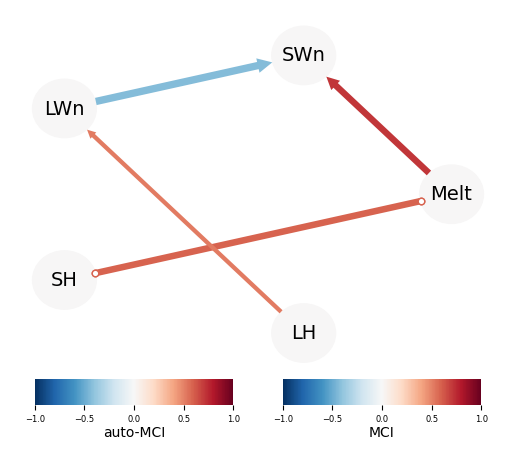

In [69]:
# alpha = 0.1
pc_alpha_bootstrap = 0.05
boot_samples = 100
tau_max = 12

# The block-length of the bootstrap can optionally be used to better deal with autocorrelation, 
# but its effect was not yet evaluated.
boot_blocklength = 15

## Create PCMCI object to call run_bootstrap_of
#pcmci = PCMCI(dataframe=dataframe,
#        cond_ind_test=robustparcorr,
#        verbosity=0,
#        )

# Call bootstrap for the chosen method (here 'run_pcmciplus') and pass method arguments  
results = pcmci.run_bootstrap_of(
        method='run_pcmciplus', 
        method_args={'tau_max':tau_max, 'pc_alpha':pc_alpha_bootstrap, 'contemp_collider_rule':'conservative'}, 
        boot_samples=boot_samples,
        boot_blocklength=boot_blocklength,
        seed=123)

# Output graph, link frequencies (confidence measure), and mean test statistic values (val_mat)
boot_linkfreq = results['summary_results']['link_frequency']
boot_graph = results['summary_results']['most_frequent_links']
val_mat = results['summary_results']['val_matrix_mean']

# Plot
tp.plot_graph(
    graph = boot_graph,
    val_matrix= val_mat,
    link_width = boot_linkfreq,
    var_names=var_names,
    node_size=0.4,
    node_label_size=14,
    node_ticks=0.5,
    edge_ticks=0.5,
    link_label_fontsize=14,
    arrow_linewidth=10.0,
    );

plot_dir = home_dir+'2023-GrIS-melt-causality/plot/RACMO/clean_mask/1975_2014/'
#plt.savefig(plot_dir+'graph_pcmciplus_bootstrap_melt_RACMO_SEB_RACMO_noGHF_realJJA_GrIS_ablation_seasonality_1965_2014_conservative_nofdrc_robustparcorr_rmmontrend_nostd_maxtau'+str(tau_max)+'_alpha'+str(pc_alpha_bootstrap)+'_bbl'+str(boot_blocklength)+'_clean.png', dpi=300, bbox_inches='tight', facecolor='w', transparent=False)

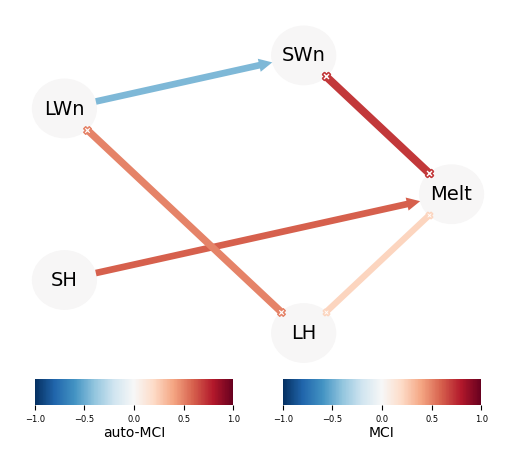

In [68]:
# alpha = 0.1
pc_alpha_bootstrap = 0.1
boot_samples = 100
tau_max = 12

# The block-length of the bootstrap can optionally be used to better deal with autocorrelation, 
# but its effect was not yet evaluated.
boot_blocklength = 9

## Create PCMCI object to call run_bootstrap_of
#pcmci = PCMCI(dataframe=dataframe,
#        cond_ind_test=robustparcorr,
#        verbosity=0,
#        )

# Call bootstrap for the chosen method (here 'run_pcmciplus') and pass method arguments  
results = pcmci.run_bootstrap_of(
        method='run_pcmciplus', 
        method_args={'tau_max':tau_max, 'pc_alpha':pc_alpha_bootstrap, 'contemp_collider_rule':'conservative'}, 
        boot_samples=boot_samples,
        boot_blocklength=boot_blocklength,
        seed=123)

# Output graph, link frequencies (confidence measure), and mean test statistic values (val_mat)
boot_linkfreq = results['summary_results']['link_frequency']
boot_graph = results['summary_results']['most_frequent_links']
val_mat = results['summary_results']['val_matrix_mean']

# Plot
tp.plot_graph(
    graph = boot_graph,
    val_matrix= val_mat,
    link_width = boot_linkfreq,
    var_names=var_names,
    node_size=0.4,
    node_label_size=14,
    node_ticks=0.5,
    edge_ticks=0.5,
    link_label_fontsize=14,
    arrow_linewidth=10.0,
    );

plot_dir = home_dir+'2023-GrIS-melt-causality/plot/RACMO/clean_mask/1975_2014/'
#plt.savefig(plot_dir+'graph_pcmciplus_bootstrap_melt_RACMO_SEB_RACMO_noGHF_realJJA_GrIS_ablation_seasonality_1965_2014_conservative_nofdrc_robustparcorr_rmmontrend_nostd_maxtau'+str(tau_max)+'_alpha'+str(pc_alpha_bootstrap)+'_bbl'+str(boot_blocklength)+'_clean.png', dpi=300, bbox_inches='tight', facecolor='w', transparent=False)

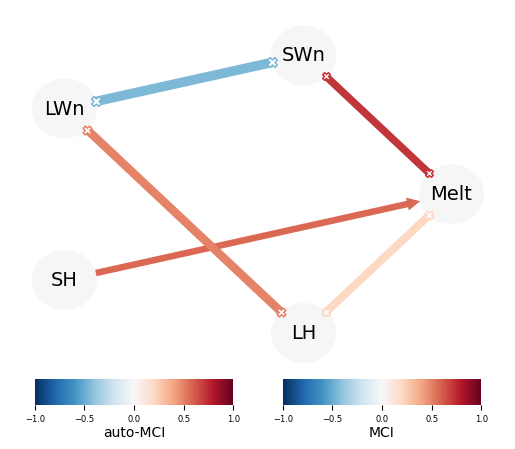

In [65]:
# alpha = 0.1
pc_alpha_bootstrap = 0.1
boot_samples = 100
tau_max = 12

# The block-length of the bootstrap can optionally be used to better deal with autocorrelation, 
# but its effect was not yet evaluated.
boot_blocklength = 12

## Create PCMCI object to call run_bootstrap_of
#pcmci = PCMCI(dataframe=dataframe,
#        cond_ind_test=robustparcorr,
#        verbosity=0,
#        )

# Call bootstrap for the chosen method (here 'run_pcmciplus') and pass method arguments  
results = pcmci.run_bootstrap_of(
        method='run_pcmciplus', 
        method_args={'tau_max':tau_max, 'pc_alpha':pc_alpha_bootstrap, 'contemp_collider_rule':'majority'}, 
        boot_samples=boot_samples,
        boot_blocklength=boot_blocklength,
        seed=123)

# Output graph, link frequencies (confidence measure), and mean test statistic values (val_mat)
boot_linkfreq = results['summary_results']['link_frequency']
boot_graph = results['summary_results']['most_frequent_links']
val_mat = results['summary_results']['val_matrix_mean']

# Plot
tp.plot_graph(
    graph = boot_graph,
    val_matrix= val_mat,
    link_width = boot_linkfreq,
    var_names=var_names,
    node_size=0.4,
    node_label_size=14,
    node_ticks=0.5,
    edge_ticks=0.5,
    link_label_fontsize=14,
    arrow_linewidth=10.0,
    );

plot_dir = home_dir+'2023-GrIS-melt-causality/plot/RACMO/clean_mask/1975_2014/'
#plt.savefig(plot_dir+'graph_pcmciplus_bootstrap_melt_RACMO_SEB_RACMO_noGHF_realJJA_GrIS_ablation_seasonality_1965_2014_conservative_nofdrc_robustparcorr_rmmontrend_nostd_maxtau'+str(tau_max)+'_alpha'+str(pc_alpha_bootstrap)+'_bbl'+str(boot_blocklength)+'_clean.png', dpi=300, bbox_inches='tight', facecolor='w', transparent=False)

In [30]:
boot_graph[0,:,:]

array([['', '', '', '', '', '', '', '', '', '', '', '', ''],
       ['-->', '', '', '', '', '', '', '', '', '', '', '', ''],
       ['', '', '', '', '', '', '', '', '', '', '', '', ''],
       ['<--', '', '-->', '', '', '', '', '', '', '', '', '', ''],
       ['', '', '', '', '', '', '', '', '', '', '', '', '']], dtype='<U3')

In [31]:
np.where(boot_graph != '', val_mat, np.NaN)[0,:,:]

array([[        nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan],
       [ 0.64472514,         nan,         nan,         nan,         nan,
                nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan],
       [        nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan],
       [ 0.62892719,         nan, -0.22507399,         nan,         nan,
                nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan],
       [        nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan]])

In [34]:
results['summary_results']

{'most_frequent_links': array([[['', '', '', '', '', '', '', '', '', '', '', '', ''],
         ['-->', '', '', '', '', '', '', '', '', '', '', '', ''],
         ['', '', '', '', '', '', '', '', '', '', '', '', ''],
         ['<--', '', '-->', '', '', '', '', '', '', '', '', '', ''],
         ['', '', '', '', '', '', '', '', '', '', '', '', '']],
 
        [['<--', '', '', '', '', '', '', '', '', '', '', '', ''],
         ['', '', '', '', '', '', '', '', '', '', '', '', ''],
         ['<--', '', '', '', '', '', '', '', '', '', '', '', ''],
         ['', '', '', '', '', '', '', '', '', '', '', '', ''],
         ['', '', '', '', '', '', '', '', '', '', '', '', '']],
 
        [['', '', '', '', '', '', '', '', '', '', '', '', ''],
         ['-->', '', '', '', '', '', '', '', '', '', '', '', ''],
         ['', '', '', '', '', '', '', '', '', '', '', '', ''],
         ['', '', '', '', '', '', '', '', '', '', '', '', ''],
         ['x-x', '', '', '', '', '', '', '', '', '', '', '', '']],
 
  

In [54]:
#The links can also be exported to a csv file:
tp.write_csv(
    val_matrix=val_mat,
    graph=boot_graph,
    var_names=var_names,
    link_width=boot_linkfreq,
    save_name=home_dir+'2023-GrIS-melt-causality/data/RACMO/graph_pcmciplus_bootstrap_melt_RACMO_SEB_RACMO_noGHF_realJJA_GrIS_ablation_seasonality_1965_2014_conservative_nofdrc_robustparcorr_rmmontrend_nostd_maxtau'+str(tau_max)+'_alpha'+str(pc_alpha_bootstrap)+'_bbl'+str(boot_blocklength)+'_clean.csv',
    digits=5,
)

In [55]:
save_name = home_dir+'2023-GrIS-melt-causality/data/RACMO/graph_pcmciplus_bootstrap_melt_RACMO_SEB_RACMO_noGHF_realJJA_GrIS_ablation_seasonality_1965_2014_conservative_nofdrc_robustparcorr_rmmontrend_nostd_maxtau'+str(tau_max)+'_alpha'+str(pc_alpha_bootstrap)+'_bbl'+str(boot_blocklength)+'_clean.csv'
pd.read_csv(save_name)

,Variable i,Variable j,Time lag of i,Link type i --- j,Link value,Link width
0,Melt,SWn,0,-->,0.74897,0.39
1,Melt,SH,0,<--,0.60131,0.45
2,SWn,LWn,0,<--,-0.48550,0.55
3,LWn,LH,0,x-x,0.43711,0.41


In [56]:
# Save for plotting (since the format saved by tp.write_csv is hard to use)
save_name = home_dir+'2023-GrIS-melt-causality/data/RACMO/graph_pcmciplus_bootstrap_melt_RACMO_SEB_RACMO_noGHF_realJJA_GrIS_ablation_seasonality_1965_2014_conservative_nofdrc_robustparcorr_rmmontrend_nostd_maxtau'+str(tau_max)+'_alpha'+str(pc_alpha_bootstrap)+'_bbl'+str(boot_blocklength)+'_clean_forplot.npz'

np.savez(save_name,
         val_matrix=val_mat,
         graph=boot_graph,
         link_width=boot_linkfreq,
         var_names=var_names)

### tau_max = 6

##### without seasonal cycle, max_lag=6, pc_alpha=0.1

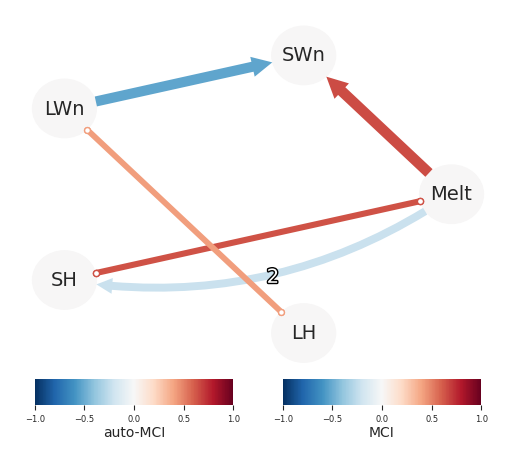

In [28]:
# alpha = 0.1
pc_alpha_bootstrap = 0.1
boot_samples = 100
tau_max = 6

# The block-length of the bootstrap can optionally be used to better deal with autocorrelation, 
# but its effect was not yet evaluated.
boot_blocklength = 1

## Create PCMCI object to call run_bootstrap_of
pcmci = PCMCI(dataframe=dataframe,
        cond_ind_test=robustparcorr,
        verbosity=0,
        )

# Call bootstrap for the chosen method (here 'run_pcmciplus') and pass method arguments  
results = pcmci.run_bootstrap_of(
        method='run_pcmciplus', 
        method_args={'tau_max':tau_max, 'pc_alpha':pc_alpha_bootstrap, 'contemp_collider_rule':'conservative'}, 
        boot_samples=boot_samples,
        boot_blocklength=boot_blocklength,
        seed=123)

# Output graph, link frequencies (confidence measure), and mean test statistic values (val_mat)
boot_linkfreq = results['summary_results']['link_frequency']
boot_graph = results['summary_results']['most_frequent_links']
val_mat = results['summary_results']['val_matrix_mean']

# Plot
tp.plot_graph(
    graph = boot_graph,
    val_matrix= val_mat,
    link_width = boot_linkfreq,
    var_names=dataframe.var_names,
    node_size=0.4,
    node_label_size=14,
    node_ticks=0.5,
    edge_ticks=0.5,
    link_label_fontsize=14,
    arrow_linewidth=10.0,
    );

plot_dir = home_dir+'2023-GrIS-melt-causality/plot/RACMO/clean_mask/'
plt.savefig(plot_dir+'graph_pcmciplus_bootstrap_melt_RACMO_SEB_RACMO_noGHF_realJJA_GrIS_ablation_seasonality_1940_1969_conservative_nofdrc_robustparcorr_maxtau'+str(tau_max)+'_alpha'+str(pc_alpha_bootstrap)+'_clean.png', dpi=300, bbox_inches='tight', facecolor='w', transparent=False)

### tau_max = 18

##### without seasonal cycle, max_lag=18, pc_alpha=0.1

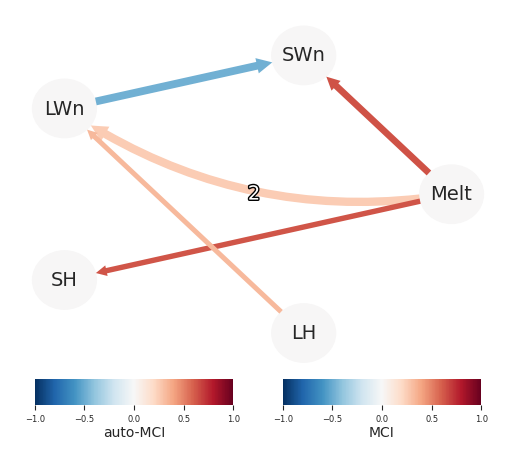

In [29]:
# alpha = 0.1
pc_alpha_bootstrap = 0.1
boot_samples = 100
tau_max = 18

# The block-length of the bootstrap can optionally be used to better deal with autocorrelation, 
# but its effect was not yet evaluated.
boot_blocklength = 1

## Create PCMCI object to call run_bootstrap_of
pcmci = PCMCI(dataframe=dataframe,
        cond_ind_test=robustparcorr,
        verbosity=0,
        )

# Call bootstrap for the chosen method (here 'run_pcmciplus') and pass method arguments  
results = pcmci.run_bootstrap_of(
        method='run_pcmciplus', 
        method_args={'tau_max':tau_max, 'pc_alpha':pc_alpha_bootstrap, 'contemp_collider_rule':'conservative'}, 
        boot_samples=boot_samples,
        boot_blocklength=boot_blocklength,
        seed=123)

# Output graph, link frequencies (confidence measure), and mean test statistic values (val_mat)
boot_linkfreq = results['summary_results']['link_frequency']
boot_graph = results['summary_results']['most_frequent_links']
val_mat = results['summary_results']['val_matrix_mean']

# Plot
tp.plot_graph(
    graph = boot_graph,
    val_matrix= val_mat,
    link_width = boot_linkfreq,
    var_names=dataframe.var_names,
    node_size=0.4,
    node_label_size=14,
    node_ticks=0.5,
    edge_ticks=0.5,
    link_label_fontsize=14,
    arrow_linewidth=10.0,
    );

plot_dir = home_dir+'2023-GrIS-melt-causality/plot/RACMO/clean_mask/'
plt.savefig(plot_dir+'graph_pcmciplus_bootstrap_melt_RACMO_SEB_RACMO_noGHF_realJJA_GrIS_ablation_seasonality_1940_1969_conservative_nofdrc_robustparcorr_maxtau'+str(tau_max)+'_alpha'+str(pc_alpha_bootstrap)+'_clean.png', dpi=300, bbox_inches='tight', facecolor='w', transparent=False)

In [55]:
#The links can also be exported to a csv file:
tp.write_csv(
    val_matrix=val_mat,
    graph=boot_graph,
    var_names=dataframe.var_names,
    link_width=boot_linkfreq,
    save_name=home_dir+'2023-GrIS-melt-causality/data/RACMO/graph_pcmciplus_bootstrap_melt_RACMO_SEB_RACMO_noGHF_realJJA_GrIS_ablation_seasonality_1940_1969_conservative_nofdrc_robustparcorr_maxtau'+str(tau_max)+'_alpha'+str(pc_alpha_bootstrap)+'_clean.csv',
    digits=5,
)

In [56]:
save_name = home_dir+'2023-GrIS-melt-causality/data/RACMO/graph_pcmciplus_bootstrap_melt_RACMO_SEB_RACMO_noGHF_realJJA_GrIS_ablation_seasonality_1940_1969_conservative_nofdrc_robustparcorr_maxtau'+str(tau_max)+'_alpha'+str(pc_alpha_bootstrap)+'_clean.csv'
pd.read_csv(save_name)

,Variable i,Variable j,Time lag of i,Link type i --- j,Link value,Link width
0,Melt,SWn,0,-->,0.64473,0.61
1,Melt,SH,0,<--,0.62893,0.36
2,Melt,SH,2,-->,-0.22507,0.53
3,SWn,LWn,0,<--,-0.48090,0.70
4,LWn,LH,0,x-x,0.37699,0.60


In [57]:
# Save for plotting (since the format saved by tp.write_csv is hard to use)
save_name = home_dir+'2023-GrIS-melt-causality/data/RACMO/graph_pcmciplus_bootstrap_melt_RACMO_SEB_RACMO_noGHF_realJJA_GrIS_ablation_seasonality_1940_1969_conservative_nofdrc_robustparcorr_maxtau'+str(tau_max)+'_alpha'+str(pc_alpha_bootstrap)+'_clean_forplot.npz'

np.savez(save_name,
         val_matrix=val_mat,
         graph=boot_graph,
         link_width=boot_linkfreq,
         var_names=dataframe.var_names)

### tau_max = 5

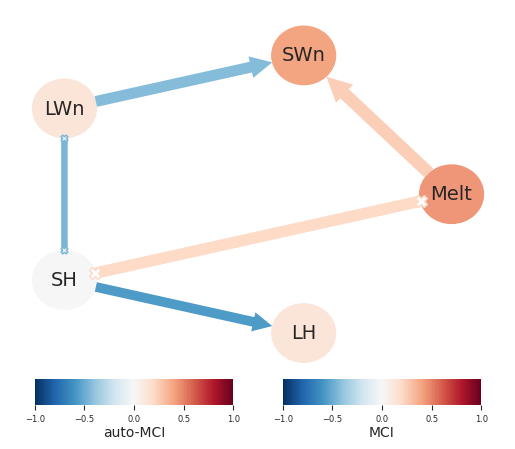

In [43]:
# alpha = 0.01
pc_alpha_bootstrap = 0.01
boot_samples = 100
tau_max = 5

# The block-length of the bootstrap can optionally be used to better deal with autocorrelation, 
# but its effect was not yet evaluated.
boot_blocklength = 1

## Create PCMCI object to call run_bootstrap_of
pcmci = PCMCI(dataframe=dataframe,
        cond_ind_test=parcorr,
        verbosity=0,
        )

# Call bootstrap for the chosen method (here 'run_pcmciplus') and pass method arguments  
results = pcmci.run_bootstrap_of(
        method='run_pcmciplus', 
        method_args={'tau_max':tau_max, 'pc_alpha':pc_alpha_bootstrap, 'contemp_collider_rule':'conservative'}, 
        boot_samples=boot_samples,
        boot_blocklength=boot_blocklength,
        seed=123)

# Output graph, link frequencies (confidence measure), and mean test statistic values (val_mat)
boot_linkfreq = results['summary_results']['link_frequency']
boot_graph = results['summary_results']['most_frequent_links']
val_mat = results['summary_results']['val_matrix_mean']

# Plot
tp.plot_graph(
    graph = boot_graph,
    val_matrix= val_mat,
    link_width = boot_linkfreq,
    var_names=dataframe.var_names,
    node_size=0.4,
    node_label_size=14,
    node_ticks=0.5,
    edge_ticks=0.5,
    link_label_fontsize=14,
    arrow_linewidth=10.0,
    );

plt.savefig(home_dir+'GrIS_melt_causality/plot/RACMO_ERA5/graph_pcmciplus_bootstrap_melt_RACMO_SEB_ERA5_noGHF_JJA_GrIS_ablation_1958_2022_conservative_nofdrc_alpha001_taumax5.png', dpi = 300, bbox_inches = 'tight', facecolor='w', transparent = False)

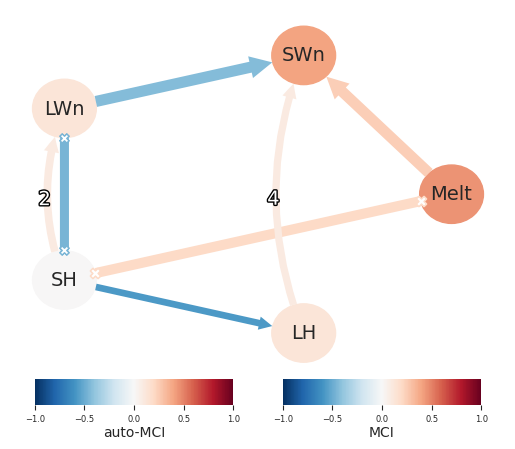

In [44]:
# alpha = 0.025
pc_alpha_bootstrap = 0.025
boot_samples = 100
tau_max = 5

# The block-length of the bootstrap can optionally be used to better deal with autocorrelation, 
# but its effect was not yet evaluated.
boot_blocklength = 1

## Create PCMCI object to call run_bootstrap_of
pcmci = PCMCI(dataframe=dataframe,
        cond_ind_test=parcorr,
        verbosity=0,
        )

# Call bootstrap for the chosen method (here 'run_pcmciplus') and pass method arguments  
results = pcmci.run_bootstrap_of(
        method='run_pcmciplus', 
        method_args={'tau_max':tau_max, 'pc_alpha':pc_alpha_bootstrap, 'contemp_collider_rule':'conservative'}, 
        boot_samples=boot_samples,
        boot_blocklength=boot_blocklength,
        seed=123)

# Output graph, link frequencies (confidence measure), and mean test statistic values (val_mat)
boot_linkfreq = results['summary_results']['link_frequency']
boot_graph = results['summary_results']['most_frequent_links']
val_mat = results['summary_results']['val_matrix_mean']

# Plot
tp.plot_graph(
    graph = boot_graph,
    val_matrix= val_mat,
    link_width = boot_linkfreq,
    var_names=dataframe.var_names,
    node_size=0.4,
    node_label_size=14,
    node_ticks=0.5,
    edge_ticks=0.5,
    link_label_fontsize=14,
    arrow_linewidth=10.0,
    );

plt.savefig(home_dir+'GrIS_melt_causality/plot/RACMO_ERA5/graph_pcmciplus_bootstrap_melt_RACMO_SEB_ERA5_noGHF_JJA_GrIS_ablation_1958_2022_conservative_nofdrc_alpha0025_taumax5.png', dpi = 300, bbox_inches = 'tight', facecolor='w', transparent = False)

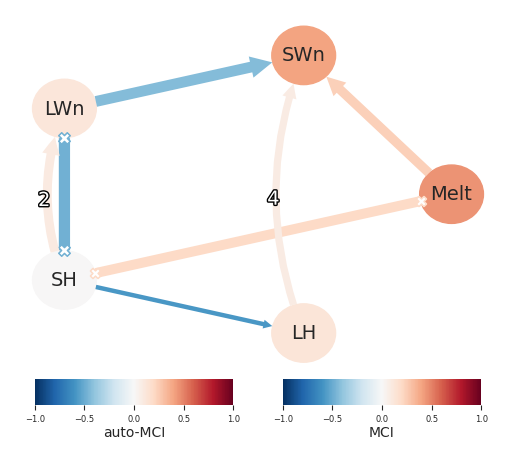

In [45]:
# alpha = 0.05
pc_alpha_bootstrap = 0.05
boot_samples = 100
tau_max = 5

# The block-length of the bootstrap can optionally be used to better deal with autocorrelation, 
# but its effect was not yet evaluated.
boot_blocklength = 1

## Create PCMCI object to call run_bootstrap_of
pcmci = PCMCI(dataframe=dataframe,
        cond_ind_test=parcorr,
        verbosity=0,
        )

# Call bootstrap for the chosen method (here 'run_pcmciplus') and pass method arguments  
results = pcmci.run_bootstrap_of(
        method='run_pcmciplus', 
        method_args={'tau_max':tau_max, 'pc_alpha':pc_alpha_bootstrap, 'contemp_collider_rule':'conservative'}, 
        boot_samples=boot_samples,
        boot_blocklength=boot_blocklength,
        seed=123)

# Output graph, link frequencies (confidence measure), and mean test statistic values (val_mat)
boot_linkfreq = results['summary_results']['link_frequency']
boot_graph = results['summary_results']['most_frequent_links']
val_mat = results['summary_results']['val_matrix_mean']

# Plot
tp.plot_graph(
    graph = boot_graph,
    val_matrix= val_mat,
    link_width = boot_linkfreq,
    var_names=dataframe.var_names,
    node_size=0.4,
    node_label_size=14,
    node_ticks=0.5,
    edge_ticks=0.5,
    link_label_fontsize=14,
    arrow_linewidth=10.0,
    );

plt.savefig(home_dir+'GrIS_melt_causality/plot/RACMO_ERA5/graph_pcmciplus_bootstrap_melt_RACMO_SEB_ERA5_noGHF_JJA_GrIS_ablation_1958_2022_conservative_nofdrc_alpha005_taumax5.png', dpi = 300, bbox_inches = 'tight', facecolor='w', transparent = False)

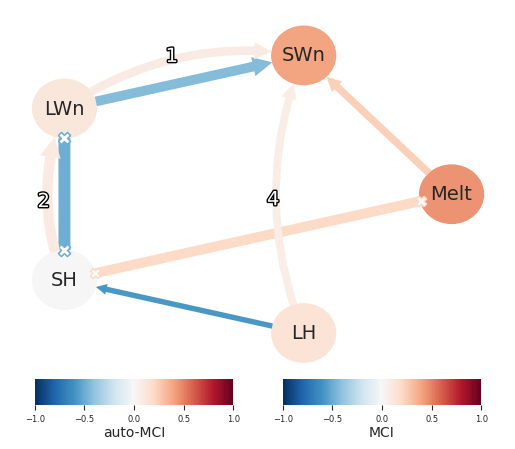

In [46]:
# alpha = 0.1
pc_alpha_bootstrap = 0.1
boot_samples = 100
tau_max = 5

# The block-length of the bootstrap can optionally be used to better deal with autocorrelation, 
# but its effect was not yet evaluated.
boot_blocklength = 1

## Create PCMCI object to call run_bootstrap_of
pcmci = PCMCI(dataframe=dataframe,
        cond_ind_test=parcorr,
        verbosity=0,
        )

# Call bootstrap for the chosen method (here 'run_pcmciplus') and pass method arguments  
results = pcmci.run_bootstrap_of(
        method='run_pcmciplus', 
        method_args={'tau_max':tau_max, 'pc_alpha':pc_alpha_bootstrap, 'contemp_collider_rule':'conservative'}, 
        boot_samples=boot_samples,
        boot_blocklength=boot_blocklength,
        seed=123)

# Output graph, link frequencies (confidence measure), and mean test statistic values (val_mat)
boot_linkfreq = results['summary_results']['link_frequency']
boot_graph = results['summary_results']['most_frequent_links']
val_mat = results['summary_results']['val_matrix_mean']

# Plot
tp.plot_graph(
    graph = boot_graph,
    val_matrix= val_mat,
    link_width = boot_linkfreq,
    var_names=dataframe.var_names,
    node_size=0.4,
    node_label_size=14,
    node_ticks=0.5,
    edge_ticks=0.5,
    link_label_fontsize=14,
    arrow_linewidth=10.0,
    );

plt.savefig(home_dir+'GrIS_melt_causality/plot/RACMO_ERA5/graph_pcmciplus_bootstrap_melt_RACMO_SEB_ERA5_noGHF_JJA_GrIS_ablation_1958_2022_conservative_nofdrc_alpha01_taumax5.png', dpi = 300, bbox_inches = 'tight', facecolor='w', transparent = False)

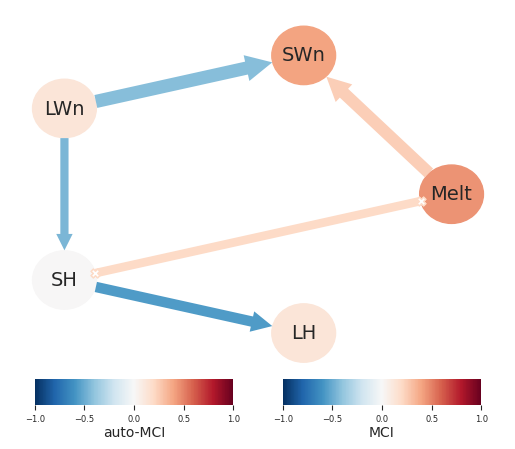

In [47]:
# alpha = None
pc_alpha_bootstrap = None
boot_samples = 100
tau_max = 5

# The block-length of the bootstrap can optionally be used to better deal with autocorrelation, 
# but its effect was not yet evaluated.
boot_blocklength = 1

## Create PCMCI object to call run_bootstrap_of
pcmci = PCMCI(dataframe=dataframe,
        cond_ind_test=parcorr,
        verbosity=0,
        )

# Call bootstrap for the chosen method (here 'run_pcmciplus') and pass method arguments  
results = pcmci.run_bootstrap_of(
        method='run_pcmciplus', 
        method_args={'tau_max':tau_max, 'pc_alpha':pc_alpha_bootstrap, 'contemp_collider_rule':'conservative'}, 
        boot_samples=boot_samples,
        boot_blocklength=boot_blocklength,
        seed=123)

# Output graph, link frequencies (confidence measure), and mean test statistic values (val_mat)
boot_linkfreq = results['summary_results']['link_frequency']
boot_graph = results['summary_results']['most_frequent_links']
val_mat = results['summary_results']['val_matrix_mean']

# Plot
tp.plot_graph(
    graph = boot_graph,
    val_matrix= val_mat,
    link_width = boot_linkfreq,
    var_names=dataframe.var_names,
    node_size=0.4,
    node_label_size=14,
    node_ticks=0.5,
    edge_ticks=0.5,
    link_label_fontsize=14,
    arrow_linewidth=10.0,
    );

plt.savefig(home_dir+'GrIS_melt_causality/plot/RACMO_ERA5/graph_pcmciplus_bootstrap_melt_RACMO_SEB_ERA5_noGHF_JJA_GrIS_ablation_1958_2022_conservative_nofdrc_alphaNone_taumax5.png', dpi = 300, bbox_inches = 'tight', facecolor='w', transparent = False)

### cond_ind_test=robustparcorr, tau_max = 15

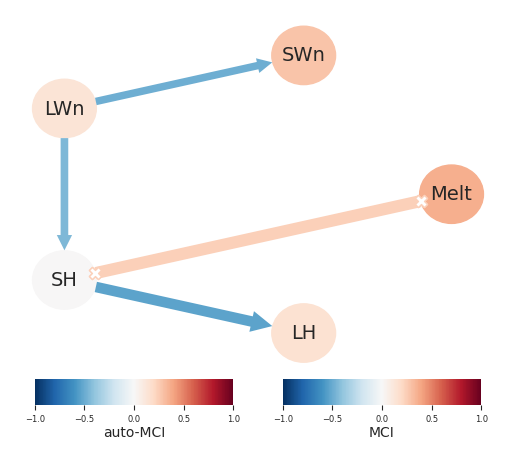

In [52]:
# alpha = 0.01
pc_alpha_bootstrap = 0.01
boot_samples = 100
tau_max = 15

# The block-length of the bootstrap can optionally be used to better deal with autocorrelation, 
# but its effect was not yet evaluated.
boot_blocklength = 1

## Create PCMCI object to call run_bootstrap_of
robustparcorr = RobustParCorr(significance='analytic')
pcmci = PCMCI(dataframe=dataframe,
        cond_ind_test=robustparcorr,
        verbosity=0,
        )

# Call bootstrap for the chosen method (here 'run_pcmciplus') and pass method arguments  
results = pcmci.run_bootstrap_of(
        method='run_pcmciplus', 
        method_args={'tau_max':tau_max, 'pc_alpha':pc_alpha_bootstrap, 'contemp_collider_rule':'conservative'}, 
        boot_samples=boot_samples,
        boot_blocklength=boot_blocklength,
        seed=123)

# Output graph, link frequencies (confidence measure), and mean test statistic values (val_mat)
boot_linkfreq = results['summary_results']['link_frequency']
boot_graph = results['summary_results']['most_frequent_links']
val_mat = results['summary_results']['val_matrix_mean']

# Plot
tp.plot_graph(
    graph = boot_graph,
    val_matrix= val_mat,
    link_width = boot_linkfreq,
    var_names=dataframe.var_names,
    node_size=0.4,
    node_label_size=14,
    node_ticks=0.5,
    edge_ticks=0.5,
    link_label_fontsize=14,
    arrow_linewidth=10.0,
    );

plt.savefig(home_dir+'GrIS_melt_causality/plot/RACMO_ERA5/graph_pcmciplus_bootstrap_melt_RACMO_SEB_ERA5_noGHF_JJA_GrIS_ablation_1958_2022_robustparcorr_conservative_nofdrc_alpha001_taumax15.png', dpi = 300, bbox_inches = 'tight', facecolor='w', transparent = False)

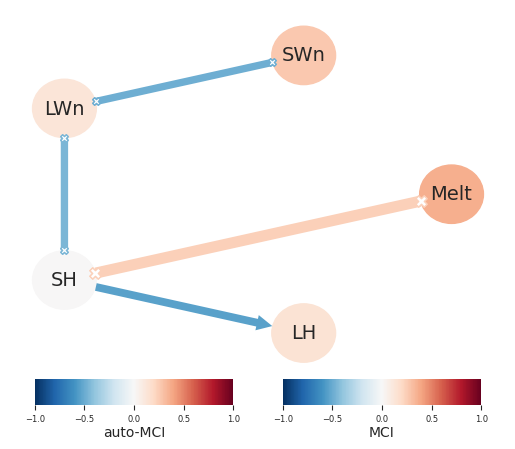

In [53]:
# alpha = 0.025
pc_alpha_bootstrap = 0.025
boot_samples = 100
tau_max = 15

# The block-length of the bootstrap can optionally be used to better deal with autocorrelation, 
# but its effect was not yet evaluated.
boot_blocklength = 1

## Create PCMCI object to call run_bootstrap_of
robustparcorr = RobustParCorr(significance='analytic')
pcmci = PCMCI(dataframe=dataframe,
        cond_ind_test=robustparcorr,
        verbosity=0,
        )

# Call bootstrap for the chosen method (here 'run_pcmciplus') and pass method arguments  
results = pcmci.run_bootstrap_of(
        method='run_pcmciplus', 
        method_args={'tau_max':tau_max, 'pc_alpha':pc_alpha_bootstrap, 'contemp_collider_rule':'conservative'}, 
        boot_samples=boot_samples,
        boot_blocklength=boot_blocklength,
        seed=123)

# Output graph, link frequencies (confidence measure), and mean test statistic values (val_mat)
boot_linkfreq = results['summary_results']['link_frequency']
boot_graph = results['summary_results']['most_frequent_links']
val_mat = results['summary_results']['val_matrix_mean']

# Plot
tp.plot_graph(
    graph = boot_graph,
    val_matrix= val_mat,
    link_width = boot_linkfreq,
    var_names=dataframe.var_names,
    node_size=0.4,
    node_label_size=14,
    node_ticks=0.5,
    edge_ticks=0.5,
    link_label_fontsize=14,
    arrow_linewidth=10.0,
    );

plt.savefig(home_dir+'GrIS_melt_causality/plot/RACMO_ERA5/graph_pcmciplus_bootstrap_melt_RACMO_SEB_ERA5_noGHF_JJA_GrIS_ablation_1958_2022_robustparcorr_conservative_nofdrc_alpha0025_taumax15.png', dpi = 300, bbox_inches = 'tight', facecolor='w', transparent = False)

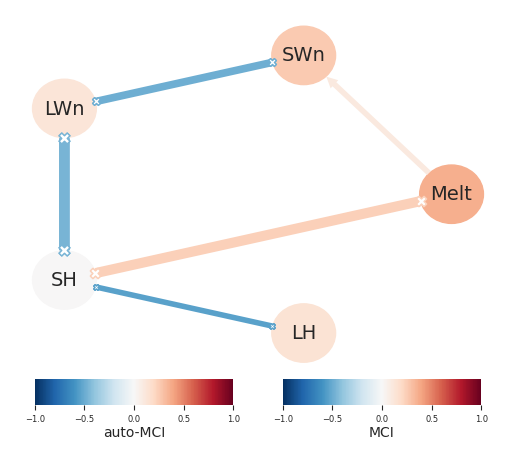

In [54]:
# alpha = 0.05
pc_alpha_bootstrap = 0.05
boot_samples = 100
tau_max = 15

# The block-length of the bootstrap can optionally be used to better deal with autocorrelation, 
# but its effect was not yet evaluated.
boot_blocklength = 1

## Create PCMCI object to call run_bootstrap_of
robustparcorr = RobustParCorr(significance='analytic')
pcmci = PCMCI(dataframe=dataframe,
        cond_ind_test=robustparcorr,
        verbosity=0,
        )

# Call bootstrap for the chosen method (here 'run_pcmciplus') and pass method arguments  
results = pcmci.run_bootstrap_of(
        method='run_pcmciplus', 
        method_args={'tau_max':tau_max, 'pc_alpha':pc_alpha_bootstrap, 'contemp_collider_rule':'conservative'}, 
        boot_samples=boot_samples,
        boot_blocklength=boot_blocklength,
        seed=123)

# Output graph, link frequencies (confidence measure), and mean test statistic values (val_mat)
boot_linkfreq = results['summary_results']['link_frequency']
boot_graph = results['summary_results']['most_frequent_links']
val_mat = results['summary_results']['val_matrix_mean']

# Plot
tp.plot_graph(
    graph = boot_graph,
    val_matrix= val_mat,
    link_width = boot_linkfreq,
    var_names=dataframe.var_names,
    node_size=0.4,
    node_label_size=14,
    node_ticks=0.5,
    edge_ticks=0.5,
    link_label_fontsize=14,
    arrow_linewidth=10.0,
    );

plt.savefig(home_dir+'GrIS_melt_causality/plot/RACMO_ERA5/graph_pcmciplus_bootstrap_melt_RACMO_SEB_ERA5_noGHF_JJA_GrIS_ablation_1958_2022_robustparcorr_conservative_nofdrc_alpha005_taumax15.png', dpi = 300, bbox_inches = 'tight', facecolor='w', transparent = False)

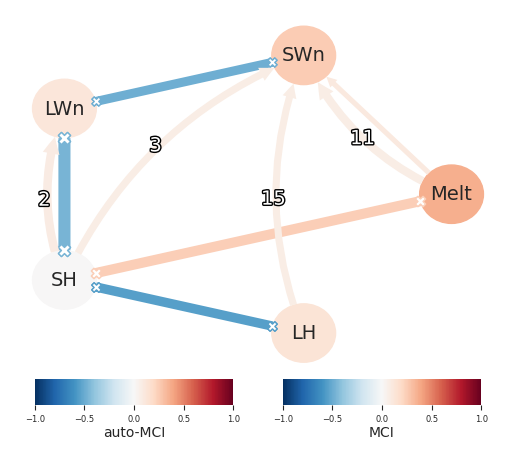

In [55]:
# alpha = 0.1
pc_alpha_bootstrap = 0.1
boot_samples = 100
tau_max = 15

# The block-length of the bootstrap can optionally be used to better deal with autocorrelation, 
# but its effect was not yet evaluated.
boot_blocklength = 1

## Create PCMCI object to call run_bootstrap_of
robustparcorr = RobustParCorr(significance='analytic')
pcmci = PCMCI(dataframe=dataframe,
        cond_ind_test=robustparcorr,
        verbosity=0,
        )

# Call bootstrap for the chosen method (here 'run_pcmciplus') and pass method arguments  
results = pcmci.run_bootstrap_of(
        method='run_pcmciplus', 
        method_args={'tau_max':tau_max, 'pc_alpha':pc_alpha_bootstrap, 'contemp_collider_rule':'conservative'}, 
        boot_samples=boot_samples,
        boot_blocklength=boot_blocklength,
        seed=123)

# Output graph, link frequencies (confidence measure), and mean test statistic values (val_mat)
boot_linkfreq = results['summary_results']['link_frequency']
boot_graph = results['summary_results']['most_frequent_links']
val_mat = results['summary_results']['val_matrix_mean']

# Plot
tp.plot_graph(
    graph = boot_graph,
    val_matrix= val_mat,
    link_width = boot_linkfreq,
    var_names=dataframe.var_names,
    node_size=0.4,
    node_label_size=14,
    node_ticks=0.5,
    edge_ticks=0.5,
    link_label_fontsize=14,
    arrow_linewidth=10.0,
    );

plt.savefig(home_dir+'GrIS_melt_causality/plot/RACMO_ERA5/graph_pcmciplus_bootstrap_melt_RACMO_SEB_ERA5_noGHF_JJA_GrIS_ablation_1958_2022_robustparcorr_conservative_nofdrc_alpha01_taumax15.png', dpi = 300, bbox_inches = 'tight', facecolor='w', transparent = False)

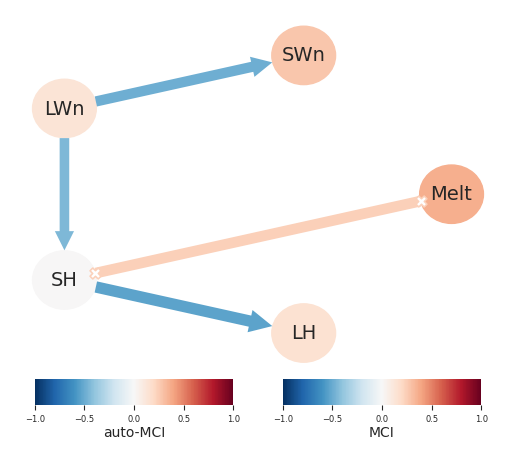

In [56]:
# alpha = None
pc_alpha_bootstrap = None
boot_samples = 100
tau_max = 15

# The block-length of the bootstrap can optionally be used to better deal with autocorrelation, 
# but its effect was not yet evaluated.
boot_blocklength = 1

## Create PCMCI object to call run_bootstrap_of
robustparcorr = RobustParCorr(significance='analytic')
pcmci = PCMCI(dataframe=dataframe,
        cond_ind_test=robustparcorr,
        verbosity=0,
        )

# Call bootstrap for the chosen method (here 'run_pcmciplus') and pass method arguments  
results = pcmci.run_bootstrap_of(
        method='run_pcmciplus', 
        method_args={'tau_max':tau_max, 'pc_alpha':pc_alpha_bootstrap, 'contemp_collider_rule':'conservative'}, 
        boot_samples=boot_samples,
        boot_blocklength=boot_blocklength,
        seed=123)

# Output graph, link frequencies (confidence measure), and mean test statistic values (val_mat)
boot_linkfreq = results['summary_results']['link_frequency']
boot_graph = results['summary_results']['most_frequent_links']
val_mat = results['summary_results']['val_matrix_mean']

# Plot
tp.plot_graph(
    graph = boot_graph,
    val_matrix= val_mat,
    link_width = boot_linkfreq,
    var_names=dataframe.var_names,
    node_size=0.4,
    node_label_size=14,
    node_ticks=0.5,
    edge_ticks=0.5,
    link_label_fontsize=14,
    arrow_linewidth=10.0,
    );

plt.savefig(home_dir+'GrIS_melt_causality/plot/RACMO_ERA5/graph_pcmciplus_bootstrap_melt_RACMO_SEB_ERA5_noGHF_JJA_GrIS_ablation_1958_2022_robustparcorr_conservative_nofdrc_alphaNone_taumax15.png', dpi = 300, bbox_inches = 'tight', facecolor='w', transparent = False)

### cond_ind_test=gpdc, tau_max = 15

Couldn't finish with bootstrap

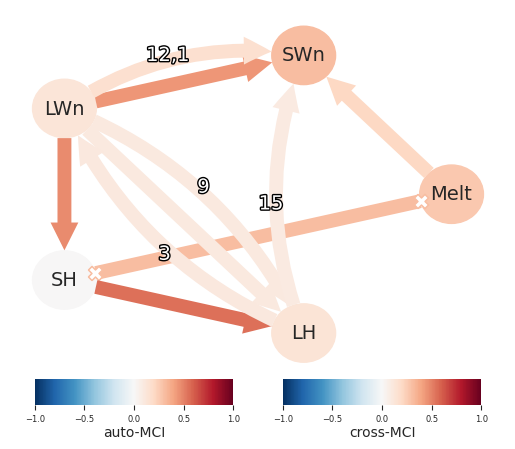

In [66]:
## alpha = 0.05

# Create PCMCI object
gpdc = GPDC(significance='analytic', gp_params=None)
pcmci = PCMCI(dataframe=dataframe,
        cond_ind_test=gpdc,
        verbosity=0,
        )

# Run pcmciplus
results = pcmci.run_pcmciplus(tau_min=0, tau_max=15, pc_alpha=0.05, contemp_collider_rule='conservative') #reset_lagged_links=True adds more links to piControl case, not 4xext

# Output graph, link frequencies (confidence measure), and mean test statistic values (val_mat)
tp.plot_graph(
    val_matrix=results['val_matrix'],
    graph=results['graph'],
    var_names=var_names,
    link_colorbar_label='cross-MCI',
    node_colorbar_label='auto-MCI',
    node_size=0.4,
    node_label_size=14,
    node_ticks=0.5,
    edge_ticks=0.5,
    link_label_fontsize=14,
    arrow_linewidth=10.0,
    );

plt.savefig(home_dir+'GrIS_melt_causality/plot/RACMO_ERA5/graph_pcmciplus_melt_RACMO_SEB_ERA5_noGHF_JJA_GrIS_ablation_1958_2022_gpdc_conservative_nofdrc.png', dpi = 300, bbox_inches = 'tight', facecolor='w', transparent = False)